# Borzoi model performance

In [1]:
# Setup and load required libraries
library(here)
devtools::load_all("/home/aviezerl/src/misha")
library(misha.ext)
library(tidyverse)
library(ggrepel)
library(tgutil)

options(gmax.data.size = 1e10)
options(gmultitasking = FALSE)
doMC::registerDoMC(cores = 72)

# Source utility functions
source(here("analysis/borzoi_utils.R"))
source(here("analysis/borzoi-plot.R"))

vertical_labs <- function() {
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
}

# Setup misha
setwd(here())
gsetroot("/home/aviezerl/mm10")
gdb.reload()

here() starts at /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm

ℹ Loading misha

Attaching package: ‘misha.ext’


The following objects are masked from ‘package:misha’:

    gintervals.mark_overlaps, gintervals.normalize


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::edition_get()   masks testthat::edition_get()
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ readr::local_edition() masks testthat::local_edition()
✖ tibble::repair_names() masks misha::repair_names()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# ============================================================
# Configuration
# ============================================================
# Centralized configuration for all analysis parameters

CONFIG <- list(
    # Chromosome splits
    test_chroms = c("chr4", "chr10", "chr14", "chr15"),
    val_chroms = c("chr8", "chr9"),

    # Thresholds
    T_q = 0.98,
    context_size = 200,
    iterator_size = 100,

    # Parallel processing
    n_cores = 72,

    # Reference tracks
    obs_k27_track = "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm",
    obs_k4_track = "jk.epipcg.pcg.CRJK_0411_k4me3_wt_to_wt_eb_d3",

    # SNS tracks
    sns_lm_track = "jk.epipcg.pred.eb4_xgb_lm_seeds",
    sns_brz2k_track = "jk.epipcg.pred.eb4_xgb_brz2k_seeds",

    # Output paths
    output_dir = here("output/borzoi-stats"),

    # Plot styling
    colors = list(
        train = "#2166AC",
        test = "#D6604D",
        val = "#7570B3"
    ),
    
    # RF values for comparison
    rf_values = c("1k", "2k", "4k", "16k", "64k", "128k", "256k", "524k"),
    rf_numeric = c(1024, 2048, 4096, 16384, 65536, 131072, 262144, 524288)
)

# Derived expressions
obs_k27_expr <- paste0("log2(1 + ", CONFIG$obs_k27_track, ")")
obs_k4_expr <- paste0("log2(1 + ", CONFIG$obs_k4_track, ")")

# Convenience aliases (for backward compatibility during refactor)
test_chroms <- CONFIG$test_chroms
val_chroms <- CONFIG$val_chroms

message("Configuration loaded successfully")

Configuration loaded successfully



In [3]:
# ============================================================
# Helper Functions
# ============================================================

#' Generic track table builder from genome configs
#'
#' @param genome_configs Tribble with genome_dir, genome_label, series, order columns
#' @param track_prefix Prefix for track names (e.g., "seq.IQ.pcg.flashzoi.")
#' @param track_suffix_k27 Suffix for K27 tracks (e.g., ".rf524k_EB4_cnt")
#' @param track_suffix_k4 Suffix for K4 tracks (default: track_suffix_k27 + "_k4")
#' @param col_name_suffix_fn Optional function to modify col_name based on row
#' @return Track table with columns: genome_dir, genome_label, series, order, track_name, col_name, mark
build_track_table <- function(genome_configs, track_prefix, track_suffix_k27, 
                               track_suffix_k4 = NULL,
                               col_name_suffix_fn = function(row) "") {
    if (is.null(track_suffix_k4)) {
        track_suffix_k4 <- paste0(track_suffix_k27, "_k4")
    }
    
    track_tbl <- bind_rows(
        # K27 tracks
        genome_configs %>%
            rowwise() %>%
            mutate(
                track_name = paste0(track_prefix, genome_dir, track_suffix_k27),
                col_name = paste0(genome_dir, col_name_suffix_fn(cur_data()), "_k27"),
                mark = "K27"
            ) %>%
            ungroup(),
        # K4 tracks
        genome_configs %>%
            rowwise() %>%
            mutate(
                track_name = paste0(track_prefix, genome_dir, track_suffix_k4),
                col_name = paste0(genome_dir, col_name_suffix_fn(cur_data()), "_k4"),
                mark = "K4"
            ) %>%
            ungroup()
    )
    
    return(track_tbl)
}

#' Validate that required tracks exist
#'
#' @param track_tbl Track table with track_name column
#' @param label Label for messages
#' @return TRUE if all tracks exist, FALSE otherwise
validate_tracks <- function(track_tbl, label = "tracks") {
    missing_tracks <- track_tbl$track_name[!sapply(track_tbl$track_name, gtrack.exists)]
    if (length(missing_tracks) > 0) {
        message(sprintf("WARNING: Missing %s:", label))
        print(unique(missing_tracks))
        return(FALSE)
    } else {
        message(sprintf("All %d %s found!", nrow(track_tbl), label))
        return(TRUE)
    }
}

#' Create interval subsets for train/test/val splits from cg_trace data
#'
#' @param cg_trace_f Filtered cg_trace data frame
#' @param test_chroms Test chromosome names (default from CONFIG)
#' @param val_chroms Validation chromosome names (default from CONFIG)
#' @return List with intervals_train, intervals_test, intervals_val
create_split_intervals <- function(cg_trace_f, 
                                    test_chroms = CONFIG$test_chroms, 
                                    val_chroms = CONFIG$val_chroms) {
    train_chroms <- setdiff(unique(cg_trace_f$chrom), c(test_chroms, val_chroms))
    
    f_train <- cg_trace_f$chrom %in% train_chroms
    f_test <- cg_trace_f$chrom %in% test_chroms
    f_val <- cg_trace_f$chrom %in% val_chroms
    
    list(
        train = cg_trace_f[f_train, c("chrom", "start", "end")],
        test = cg_trace_f[f_test, c("chrom", "start", "end")],
        val = cg_trace_f[f_val, c("chrom", "start", "end")]
    )
}

message("Helper functions loaded")

Helper functions loaded



## Checkpoint Evaluation and Selection

Evaluate all metric checkpoints (iou, loss, pearson) for each genome variant and optionally update symlinks to point to the best performing checkpoint.

In [4]:
# ============================================================
# Checkpoint Evaluation and Selection
# ============================================================
# Evaluate metric checkpoints for all genome variants analyzed in this notebook.
# Set UPDATE_SYMLINKS to TRUE to update symlinks to best checkpoints.

UPDATE_SYMLINKS <- FALSE  # Set to TRUE to update symlinks
DRY_RUN <- TRUE           # Set to FALSE to actually make changes (when UPDATE_SYMLINKS is TRUE)
SELECTION_METRIC <- "overlap_val"  # Options: "overlap_test", "overlap_val", "r2_test", "r2_val"

BASELINE <- "mm10"
SILICUS_PLUS <- c("silicusPlusCGD", "silicusPlusCRE", "silicusPlusCTCF", "silicusPlusExon",
    "silicusPlusTE", "silicusPlusRandom", "silicus")
SILICUS_TEL <- c("silicusPlusCGD", "silicusPlusCGDCre", "silicusPlusCGDCreCtcf",
    "silicusPlusCGDCreCtcfExon", "silicusPlusCGDCreCtcfExonTE")
MM10_MINUS <- c("mm10MinusCGD", "mm10MinusCGDpad1k", "mm10MinusCGDpad2k",
    "mm10MinusCRE", "mm10MinusCTCF", "mm10MinusExon",
    "mm10MinusTE", "mm10MinusRandom")

# Define genome variants to evaluate (same as used in the analyses below)
GENOME_VARIANTS <- c(
    BASELINE,
    SILICUS_PLUS,
    SILICUS_TEL,
    MM10_MINUS
)

# Remove duplicates
GENOME_VARIANTS <- unique(GENOME_VARIANTS)

In [5]:
cov_mat <- check_missing_metrics(
    genome_dirs =  SILICUS_TEL,
    track_pattern = "ft_524k_EB4_cnt",
    expected_metrics = c("iou", "loss", "pearson")
)$coverage_matrix 

stopifnot(all(cov_mat$loss & cov_mat$iou & cov_mat$pearson))

In [6]:
checkpoint_eval <- evaluate_and_select_checkpoints(
    genome_dirs = SILICUS_TEL,
    track_pattern = "ft_524k_EB4_cnt",  
    selection_metric = SELECTION_METRIC,
    update_symlinks = UPDATE_SYMLINKS,
    dry_run = DRY_RUN,
    obs_k27_track = CONFIG$obs_k27_track,
    obs_k4_track = CONFIG$obs_k4_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size
) %cache_rds% here("output/borzoi-stats/telescope_checkpoint_eval.rds")

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/telescope_checkpoint_eval.rds'



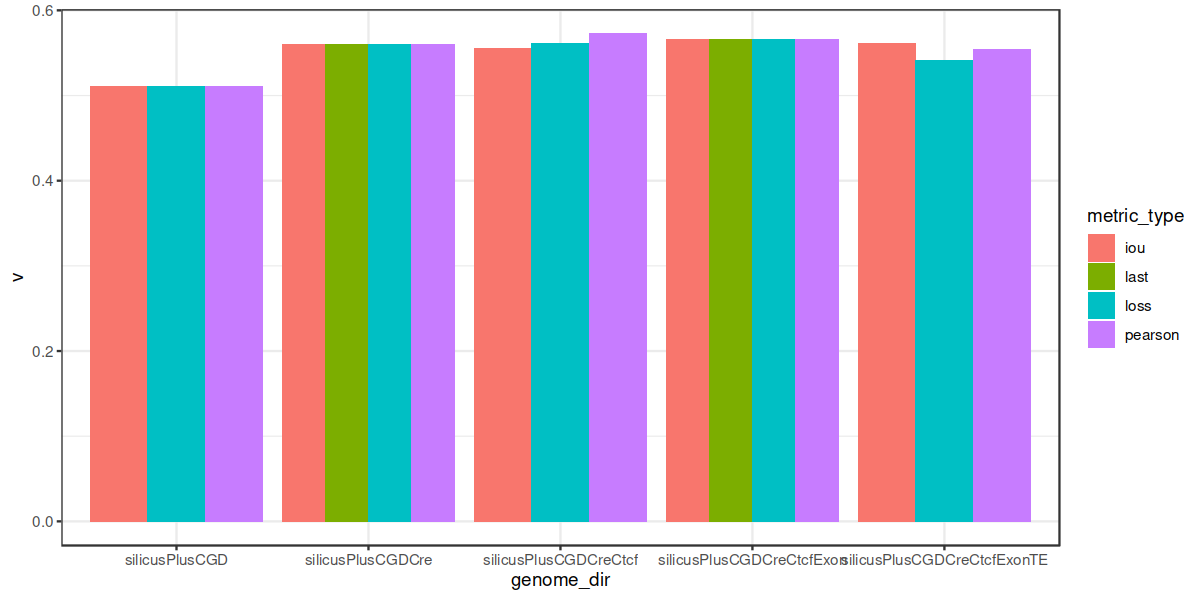

In [7]:
sps(10, 5)
checkpoint_eval$all_results %>%
        filter(!is_k4) %>%
        select(genome_dir, metric_type, v=overlap_val) %>%
        ggplot(aes(x=genome_dir, y=v, fill=metric_type)) + geom_col(position = "dodge") + theme_bw()

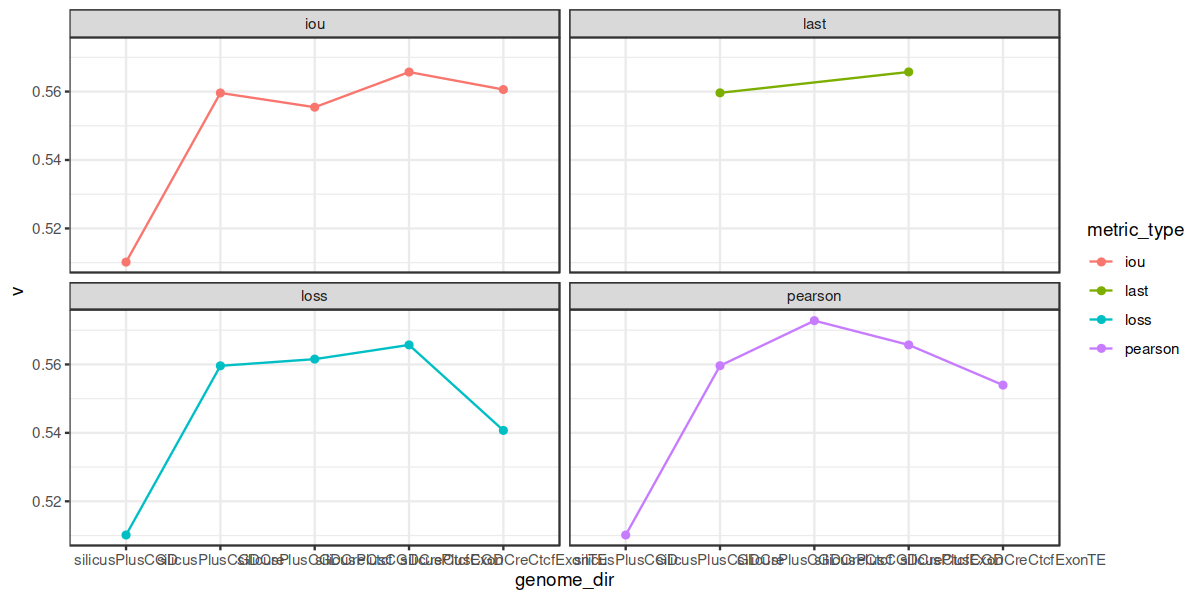

In [8]:
checkpoint_eval$all_results %>%
        filter(!is_k4) %>%
        select(genome_dir, metric_type, v=overlap_val) %>%
        ggplot(aes(x=genome_dir, y=v, color=metric_type, group = metric_type)) + geom_line() + geom_point() + theme_bw() + facet_wrap(~metric_type)

In [9]:
plyr::a_ply(checkpoint_eval$all_results %>% distinct(genome_dir, track_basename), 1, function(x) update_checkpoint_symlink(x$genome_dir, x$track_basename, "iou", dry_run = T))

  [ft_524k_EB4_cnt_cropped.track] Symlink already points to metrics/iou/ft_524k_EB4_cnt_cropped.track

  [ft_524k_EB4_cnt_k4_cropped.track] Symlink already points to metrics/iou/ft_524k_EB4_cnt_k4_cropped.track

  [ft_524k_EB4_cnt_cropped.track] Symlink already points to metrics/iou/ft_524k_EB4_cnt_cropped.track

  [ft_524k_EB4_cnt_k4_cropped.track] Symlink already points to metrics/iou/ft_524k_EB4_cnt_k4_cropped.track

  [ft_524k_EB4_cnt_cropped.track] Symlink already points to metrics/iou/ft_524k_EB4_cnt_cropped.track

  [ft_524k_EB4_cnt_k4_cropped.track] Symlink already points to metrics/iou/ft_524k_EB4_cnt_k4_cropped.track

  [ft_524k_EB4_cnt_cropped.track] Symlink already points to metrics/iou/ft_524k_EB4_cnt_cropped.track

  [ft_524k_EB4_cnt_k4_cropped.track] Symlink already points to metrics/iou/ft_524k_EB4_cnt_k4_cropped.track

  [ft_524k_EB4_cnt_cropped.track] Symlink already points to metrics/iou/ft_524k_EB4_cnt_cropped.track

  [ft_524k_EB4_cnt_k4_cropped.track] Symlink alre

In [10]:
cov_mat <- check_missing_metrics(
    genome_dirs =  SILICUS_TEL,
    track_pattern = "ft_mm10_524k_EB4_cnt",
    expected_metrics = c("iou", "loss", "pearson")
)$coverage_matrix 

# stopifnot(all(cov_mat$loss & cov_mat$iou & cov_mat$pearson))
cov_mat

genome_dir,track_basename,iou,loss,pearson
<chr>,<chr>,<lgl>,<lgl>,<lgl>
silicusPlusCGD,ft_mm10_524k_EB4_cnt_cropped,TRUE,TRUE,TRUE
silicusPlusCGD,ft_mm10_524k_EB4_cnt_k4_cropped,TRUE,TRUE,TRUE
silicusPlusCGDCre,ft_mm10_524k_EB4_cnt_cropped,TRUE,TRUE,TRUE
silicusPlusCGDCre,ft_mm10_524k_EB4_cnt_k4_cropped,TRUE,TRUE,TRUE
silicusPlusCGDCreCtcf,ft_mm10_524k_EB4_cnt_cropped,TRUE,TRUE,FALSE
silicusPlusCGDCreCtcf,ft_mm10_524k_EB4_cnt_k4_cropped,TRUE,TRUE,FALSE
silicusPlusCGDCreCtcfExon,ft_mm10_524k_EB4_cnt_cropped,TRUE,TRUE,TRUE
silicusPlusCGDCreCtcfExon,ft_mm10_524k_EB4_cnt_k4_cropped,TRUE,TRUE,TRUE
silicusPlusCGDCreCtcfExonTE,ft_mm10_524k_EB4_cnt_cropped,TRUE,TRUE,FALSE


In [11]:
checkpoint_eval_mm10 <- evaluate_and_select_checkpoints(
    genome_dirs = SILICUS_TEL,
    track_pattern = "ft_mm10_524k_EB4_cnt",  
    selection_metric = SELECTION_METRIC,
    update_symlinks = UPDATE_SYMLINKS,
    dry_run = DRY_RUN,
    obs_k27_track = CONFIG$obs_k27_track,
    obs_k4_track = CONFIG$obs_k4_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size
) %cache_rds% here("output/borzoi-stats/telescope_checkpoint_mm10_eval.rds")

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/telescope_checkpoint_mm10_eval.rds'



In [18]:
checkpoint_eval_mm10$all_results %>%
        filter(!is_k4) %>% 
        select(genome_dir, metric_type, overlap_val) %>% 
        spread(metric_type, overlap_val) 

genome_dir,iou,last,loss,pearson
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
silicusPlusCGD,0.5510590,NA,0.5510875,0.5510268
silicusPlusCGDCre,0.4297464,0.4297811,0.4297093,0.4297637
silicusPlusCGDCreCtcf,0.4760708,NA,0.4433995,NA
silicusPlusCGDCreCtcfExon,0.5373397,0.5373298,0.5373497,0.5373298
silicusPlusCGDCreCtcfExonTE,0.5307835,NA,0.4338239,NA


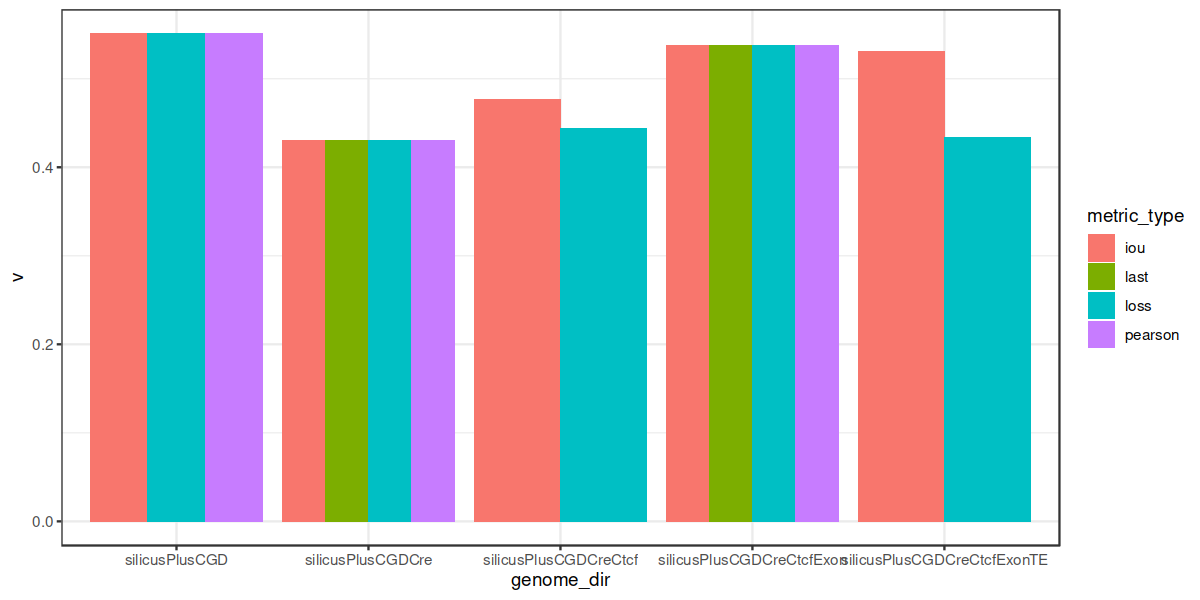

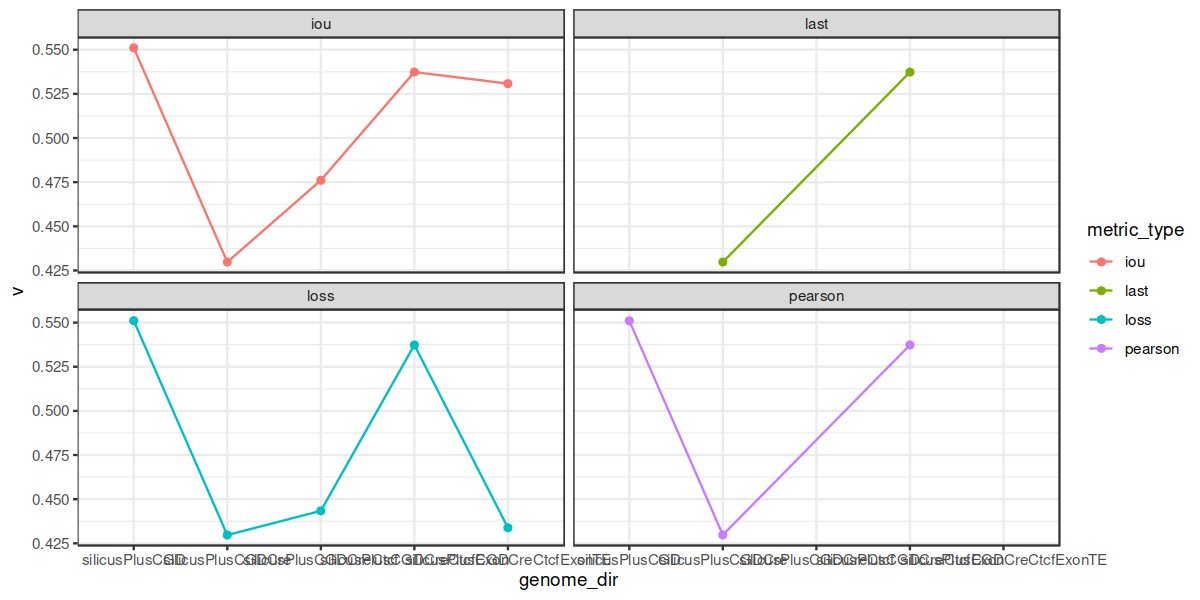

In [12]:
sps(10, 5)
checkpoint_eval_mm10$all_results %>%
        filter(!is_k4) %>%
        select(genome_dir, metric_type, v=overlap_val) %>%
        ggplot(aes(x=genome_dir, y=v, fill=metric_type)) + geom_col(position = "dodge") + theme_bw()
checkpoint_eval_mm10$all_results %>%
        filter(!is_k4) %>%
        select(genome_dir, metric_type, v=overlap_val) %>%
        ggplot(aes(x=genome_dir, y=v, color=metric_type, group = metric_type)) + geom_line() + geom_point() + theme_bw() + facet_wrap(~metric_type)

In [13]:
plyr::a_ply(checkpoint_eval_mm10$all_results %>% distinct(genome_dir, track_basename), 1, function(x) update_checkpoint_symlink(x$genome_dir, x$track_basename, "iou", dry_run = T))

  [ft_mm10_524k_EB4_cnt_cropped.track] Symlink already points to metrics/iou/ft_mm10_524k_EB4_cnt_cropped.track

  [ft_mm10_524k_EB4_cnt_k4_cropped.track] Symlink already points to metrics/iou/ft_mm10_524k_EB4_cnt_k4_cropped.track

  [ft_mm10_524k_EB4_cnt_cropped.track] Symlink already points to metrics/iou/ft_mm10_524k_EB4_cnt_cropped.track

  [ft_mm10_524k_EB4_cnt_k4_cropped.track] Symlink already points to metrics/iou/ft_mm10_524k_EB4_cnt_k4_cropped.track

  [ft_mm10_524k_EB4_cnt_cropped.track] Symlink already points to metrics/iou/ft_mm10_524k_EB4_cnt_cropped.track

  [ft_mm10_524k_EB4_cnt_k4_cropped.track] Symlink already points to metrics/iou/ft_mm10_524k_EB4_cnt_k4_cropped.track

  [ft_mm10_524k_EB4_cnt_cropped.track] Symlink already points to metrics/iou/ft_mm10_524k_EB4_cnt_cropped.track

  [ft_mm10_524k_EB4_cnt_k4_cropped.track] Symlink already points to metrics/iou/ft_mm10_524k_EB4_cnt_k4_cropped.track

  [ft_mm10_524k_EB4_cnt_cropped.track] Symlink already points to metrics

In [14]:
rf_series <- c("1k", "2k", "4k", "8k", "16k", "32k", "64k", "128k", "256k", "524k")
rf_results <- plyr::llply(rf_series, function(series) {
    evaluate_checkpoints(
            "mm10",
        paste0("rf", series, "_EB4_cnt")
    )
}, .parallel = TRUE) %>% bind_rows() %cache_rds% here("output/borzoi-stats/rf_checkpoints.rds")

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rf_checkpoints.rds'



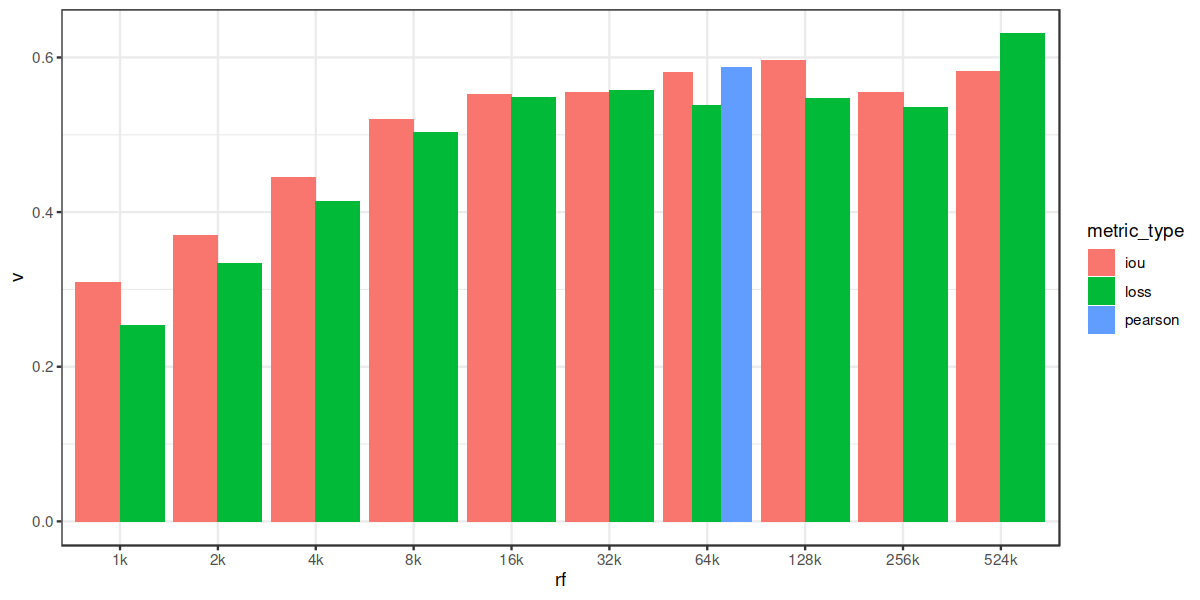

In [16]:
rf_results |> 
    filter(!is_k4) %>%    
    mutate(rf =  gsub("rf", "", gsub("k_.+", "", track_basename))) %>%
    mutate(rf = paste0(rf, "k")) %>%
    mutate(rf = factor(rf, levels = rf_series)) %>%
    select(genome_dir, metric_type, v=overlap_val, rf) %>%
    ggplot(aes(x=rf, y=v, fill=metric_type)) + geom_col(position = "dodge") + theme_bw() 

## 524k rf inference

In [ ]:
# Build track table for rf524k model inferences
# Track naming: seq.IQ.pcg.flashzoi.<genome>.rf524k_EB4_cnt[_k4]

build_rf524k_track_table <- function() {
    # Define genome directories and their labels
    genome_configs <- tribble(
        ~genome_dir, ~genome_label, ~series, ~order,
        # mm10 baseline
        "mm10", "mm10", "baseline", 0,
        # silicusPlus series
        "silicusPlusCGD", "silicus+CGD", "silicusPlus", 1,
        "silicusPlusCRE", "silicus+CRE", "silicusPlus", 2,
        "silicusPlusCTCF", "silicus+CTCF", "silicusPlus", 3,
        "silicusPlusExon", "silicus+Exon", "silicusPlus", 4,
        "silicusPlusTE", "silicus+TE", "silicusPlus", 5,
        "silicusPlusRandom", "silicus+Random", "silicusPlus", 6,
        "silicus", "silicus", "silicusPlus", 7,
        # silicusTelescope series
        "silicus", "silicus", "silicusTelescope", 1,
        "silicusPlusCGD", "silicus+CGD", "silicusTelescope", 2,
        "silicusPlusCGDCre", "silicus+CGD+CRE", "silicusTelescope", 3,
        "silicusPlusCGDCreCtcf", "silicus+CGD+CRE+CTCF", "silicusTelescope", 4,
        "silicusPlusCGDCreCtcfExon", "silicus+CGD+CRE+CTCF+Exon", "silicusTelescope", 5,
        "silicusPlusCGDCreCtcfExonTE", "silicus+CGD+CRE+CTCF+Exon+TE", "silicusTelescope", 6,
        # silicusTelescope mm10 series
        "silicus", "silicus", "silicusTelescopeMm10", 1,
        "silicusPlusCGD", "silicus+CGD", "silicusTelescopeMm10", 2,
        "silicusPlusCGDCre", "silicus+CGD+CRE", "silicusTelescopeMm10", 3,
        "silicusPlusCGDCreCtcf", "silicus+CGD+CRE+CTCF", "silicusTelescopeMm10", 4,
        "silicusPlusCGDCreCtcfExon", "silicus+CGD+CRE+CTCF+Exon", "silicusTelescopeMm10", 5,
        "silicusPlusCGDCreCtcfExonTE", "silicus+CGD+CRE+CTCF+Exon+TE", "silicusTelescopeMm10", 6,
        # mm10Minus series
        "mm10MinusCGD", "mm10-CGD", "mm10Minus", 1,
        "mm10MinusCGDpad1k", "mm10-CGD-pad1k", "mm10Minus", 2,
        "mm10MinusCGDpad2k", "mm10-CGD-pad2k", "mm10Minus", 3,
        "mm10MinusCRE", "mm10-CRE", "mm10Minus", 4,
        "mm10MinusCTCF", "mm10-CTCF", "mm10Minus", 5,
        "mm10MinusExon", "mm10-Exon", "mm10Minus", 6,
        "mm10MinusTE", "mm10-TE", "mm10Minus", 7,
        "mm10MinusRandom", "mm10-Random", "mm10Minus", 8
    )
    
    # Create track table with K27 and K4 tracks
    track_tbl <- bind_rows(
        # K27 tracks
        genome_configs %>%
            mutate(
                track_name = case_when(
                    series == "silicusTelescope" & genome_dir != "silicus" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_cropped"),
                    series == "silicusTelescopeMm10" & genome_dir != "silicus" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_mm10_524k_EB4_cnt_cropped"),
                    TRUE ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".rf524k_EB4_cnt")
                ),            
                col_name = case_when(
                    series == "silicusTelescope" ~ paste0(genome_dir, "_telescope_k27"),
                    series == "silicusTelescopeMm10" ~ paste0(genome_dir, "_telescope_mm10_k27"),
                    TRUE ~ paste0(genome_dir, "_k27")
                ),
                mark = "K27"
            ),
        # K4 tracks
        genome_configs %>%
            mutate(
                track_name = case_when(
                    series == "silicusTelescope" & genome_dir != "silicus" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_k4_cropped"),
                    series == "silicusTelescopeMm10" & genome_dir != "silicus" ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_mm10_524k_EB4_cnt_k4_cropped"),
                    TRUE ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".rf524k_EB4_cnt_k4")
                ),
                col_name = case_when(
                    series == "silicusTelescope" ~ paste0(genome_dir, "_telescope_k4"),
                    series == "silicusTelescopeMm10" ~ paste0(genome_dir, "_telescope_mm10_k4"),
                    TRUE ~ paste0(genome_dir, "_k4")
                ),
                mark = "K4"
            )
    )
    
    return(track_tbl)
}

track_tbl <- build_rf524k_track_table()

# Verify tracks exist
missing_tracks <- track_tbl$track_name[!sapply(track_tbl$track_name, gtrack.exists)]
if (length(missing_tracks) > 0) {
    message("WARNING: Missing tracks:")
    print(missing_tracks)
} else {
    message(sprintf("All %d tracks found!", nrow(track_tbl)))
}

# Display track table
track_tbl %>% 
    select(genome_label, series, order, mark, track_name) %>%
    arrange(series, order, mark)

 [1] "seq.IQ.pcg.flashzoi.silicusPlusCGD.ft_524k_EB4_cnt"                
 [2] "seq.IQ.pcg.flashzoi.silicusPlusCGDCre.ft_524k_EB4_cnt"             
 [3] "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcf.ft_524k_EB4_cnt"         
 [4] "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExon.ft_524k_EB4_cnt"     
 [5] "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExonTE.ft_524k_EB4_cnt"   
 [6] "seq.IQ.pcg.flashzoi.silicusPlusCGD.ft_524k_EB4_cnt_k4"             
 [7] "seq.IQ.pcg.flashzoi.silicusPlusCGDCre.ft_524k_EB4_cnt_k4"          
 [8] "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcf.ft_524k_EB4_cnt_k4"      
 [9] "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExon.ft_524k_EB4_cnt_k4"  
[10] "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExonTE.ft_524k_EB4_cnt_k4"


genome_label,series,order,mark,track_name
<chr>,<chr>,<dbl>,<chr>,<chr>
mm10,baseline,0,K27,seq.IQ.pcg.flashzoi.mm10.rf524k_EB4_cnt
mm10,baseline,0,K4,seq.IQ.pcg.flashzoi.mm10.rf524k_EB4_cnt_k4
mm10-CGD,mm10Minus,1,K27,seq.IQ.pcg.flashzoi.mm10MinusCGD.rf524k_EB4_cnt
mm10-CGD,mm10Minus,1,K4,seq.IQ.pcg.flashzoi.mm10MinusCGD.rf524k_EB4_cnt_k4
mm10-CGD-pad1k,mm10Minus,2,K27,seq.IQ.pcg.flashzoi.mm10MinusCGDpad1k.rf524k_EB4_cnt
mm10-CGD-pad1k,mm10Minus,2,K4,seq.IQ.pcg.flashzoi.mm10MinusCGDpad1k.rf524k_EB4_cnt_k4
mm10-CGD-pad2k,mm10Minus,3,K27,seq.IQ.pcg.flashzoi.mm10MinusCGDpad2k.rf524k_EB4_cnt
mm10-CGD-pad2k,mm10Minus,3,K4,seq.IQ.pcg.flashzoi.mm10MinusCGDpad2k.rf524k_EB4_cnt_k4
mm10-CRE,mm10Minus,4,K27,seq.IQ.pcg.flashzoi.mm10MinusCRE.rf524k_EB4_cnt


In [19]:
# Load filtered cg_trace data and setup train/test/val split
cg_trace_f <- load_cg_trace_filtered()

# Setup train/test split
borz_folds <- gintervals.load("borzoi.folds")
btrain <- borz_folds[borz_folds$type == "train", ]
btrainc <- gintervals.canonic(btrain)
gvtrack.create("borz_tr_d", btrainc, "distance")

# Using chromosome splits from CONFIG (already aliased as global variables)
cmp_gw <- gextract("borz_tr_d",
    intervals = cg_trace_f, iterator = cg_trace_f,
    colnames = "borz_tr_d"
)
cg_trace_f$borz_tr_d <- cmp_gw$borz_tr_d

# Create train/test indicator
# 0 = train chroms, near training; 1 = train chroms, far; 2 = test chroms, near; 3 = test chroms, far
train_mod_gw <- ifelse(cmp_gw$chrom %in% CONFIG$test_chroms, 2, 0) +
    ifelse(cmp_gw$borz_tr_d > 524000, 1, 0)

# Create validation indicator (separate from train/test)
# val_mod_gw: 0 = non-val chroms, 1 = val chroms near training, 2 = val chroms far
val_mod_gw <- ifelse(cmp_gw$chrom %in% CONFIG$val_chroms,
    ifelse(cmp_gw$borz_tr_d > 524000, 2, 1),
    0)

# Create interval splits using helper function
splits <- create_split_intervals(cg_trace_f)
intervals_train <- splits$train
intervals_test <- splits$test
intervals_val <- splits$val

message("Train/test split:")
print(table(train_mod_gw))
message("\nValidation split:")
print(table(val_mod_gw))
message(sprintf("\nIntervals: Train=%d, Test=%d, Val=%d", 
                nrow(intervals_train), nrow(intervals_test), nrow(intervals_val)))

message("Data setup complete!")

Loading cached filtered cg_trace...



Train/test split:



train_mod_gw
      0       1       2       3 
5808215 1220807  860923  860039 



Validation split:



val_mod_gw
      0       1       2 
7865092  712496  172396 



Intervals: Train=6144130, Test=1720962, Val=884892

Data setup complete!



In [ ]:
# Compute peak overlap metrics for K27 and K4 tracks

k27_tracks <- track_tbl %>% filter(mark == "K27")
k4_tracks <- track_tbl %>% filter(mark == "K4")

message("Computing peak overlap for K27 tracks...")
overlap_k27 <- compute_all_track_peak_overlaps(
    track_tbl = k27_tracks,
    obs_track_name = CONFIG$obs_k27_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size,
    n_cores = CONFIG$n_cores
) %fcache_rds% file.path(CONFIG$output_dir, "overlap-k27.rds")

message("\nComputing peak overlap for K4 tracks...")
overlap_k4 <- compute_all_track_peak_overlaps(
    track_tbl = k4_tracks,
    obs_track_name = CONFIG$obs_k4_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size,
    n_cores = CONFIG$n_cores
) %fcache_rds% file.path(CONFIG$output_dir, "overlap-k4.rds")

# --- Compute SNS baseline metrics (K27 only) ---
message("\n\nComputing SNS baseline metrics (K27 only)...")

sns_track_tbl <- tibble(
    track_name = c(CONFIG$sns_lm_track, CONFIG$sns_brz2k_track),
    col_name = c("sns_lm", "sns_brz2k"),
    label = c("SNS (linear)", "SNS (brz2k)")
) 

sns_exists <- all(sapply(sns_track_tbl$track_name, gtrack.exists))
if (sns_exists) {
    overlap_sns <- compute_all_track_peak_overlaps(
        track_tbl = sns_track_tbl,
        obs_track_name = CONFIG$obs_k27_track,
        context_size = CONFIG$context_size,
        T_q = CONFIG$T_q,
        test_chroms = CONFIG$test_chroms,
        val_chroms = CONFIG$val_chroms,
        iterator_size = CONFIG$iterator_size,
        n_cores = CONFIG$n_cores
    ) %cache_rds% file.path(CONFIG$output_dir, "overlap-sns.rds")
    message("\nSNS Peak Overlap (K27):")
    print(overlap_sns %>% select(col_name, train_p, test_p, val_p))
} else {
    message("WARNING: SNS tracks not found, skipping SNS baseline computation")
    overlap_sns <- NULL
}

message("\nPeak overlap calculation complete!")
message("\nK27 Peak Overlap:")
print(overlap_k27 %>% arrange(series, order) %>% select(genome_label, series, train_p, test_p, val_p))

Computing peak overlap for K27 tracks...

Computing peak overlap for 22 tracks with context=200, T_q=0.98...




Computing peak overlap for K4 tracks...

Computing peak overlap for 22 tracks with context=200, T_q=0.98...



Computing SNS baseline metrics (K27 only)...

Computing peak overlap for 2 tracks with context=200, T_q=0.98...


SNS Peak Overlap (K27):



13319 0.5652747 0.5569874
2 sns_brz2k 0.6706545 0.6136320 0.6568082



Peak overlap calculation complete!


K27 Peak Overlap:



                   genome_label   train_p    test_p     val_p
1                          mm10 0.7786554 0.6352778 0.6309726
2                      mm10-CGD 0.5357490 0.4053349 0.3973500
3                mm10-CGD-pad1k 0.4941899 0.3713572 0.3667346
4                mm10-CGD-pad2k 0.4781085 0.3595892 0.3616714
5                      mm10-CRE 0.7084344 0.5415152 0.5281945
6                     mm10-CTCF 0.7725623 0.6259485 0.6200119
7                     mm10-Exon 0.6899119 0.5434261 0.5488513
8                       mm10-TE 0.7485409 0.5978948 0.5918091
9                   mm10-Random 0.7481590 0.6001267 0.5884454
10                  silicus+CGD 0.4747556 0.4135118 0.3802234
11                  silicus+CRE 0.3847444 0.3464419 0.3111624
12                 silicus+CTCF 0.2562439 0.2491551 0.2232984
13                 silicus+Exon 0.3656707 0.3331884 0.3069912
14                   silicus+TE 0.2805456 0.2603140 0.2317657
15               silicus+Random 0.3199136 0.2963997 0.2547025
16      

In [22]:
overlap_sns %>% select(col_name, train_p, test_p, val_p)

col_name,train_p,test_p,val_p
<chr>,<dbl>,<dbl>,<dbl>
sns_lm,0.6213319,0.5652747,0.5569874
sns_brz2k,0.6706545,0.6136320,0.6568082


Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_line()`).”
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


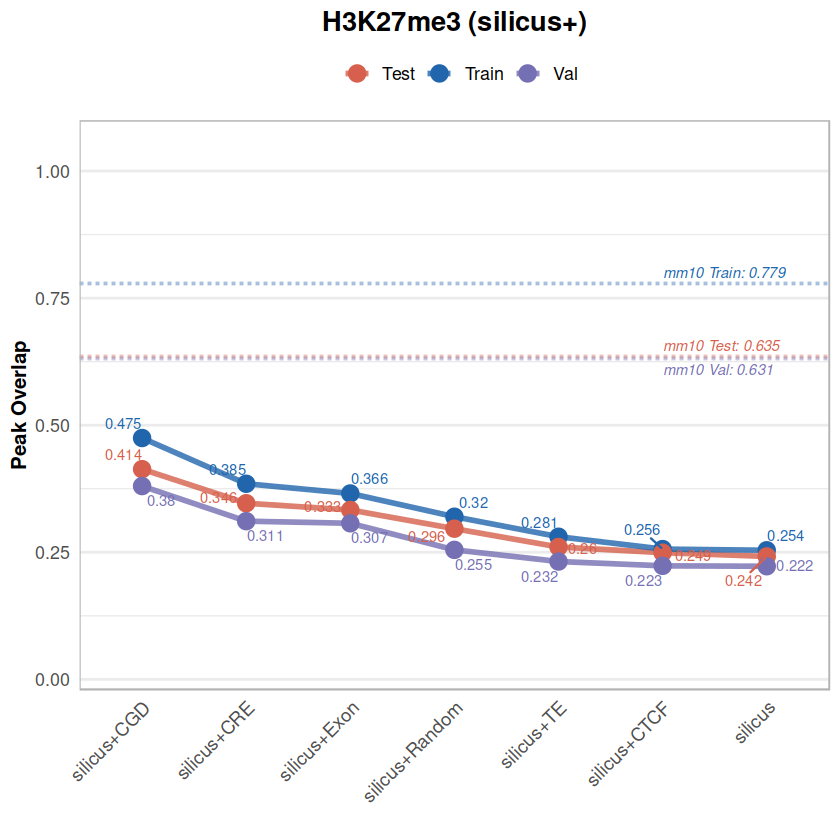

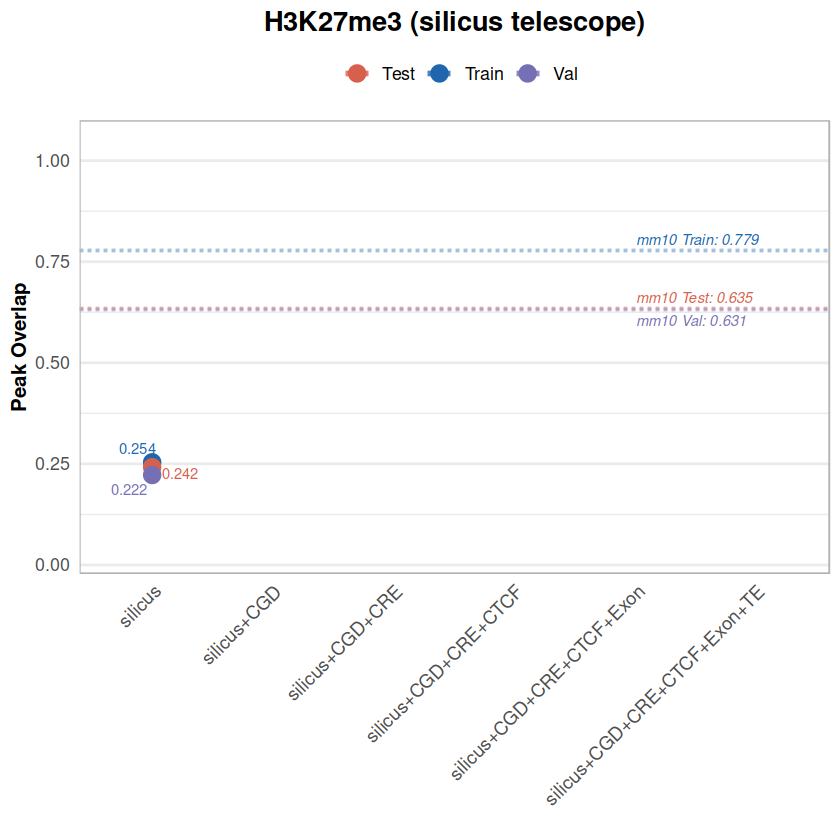

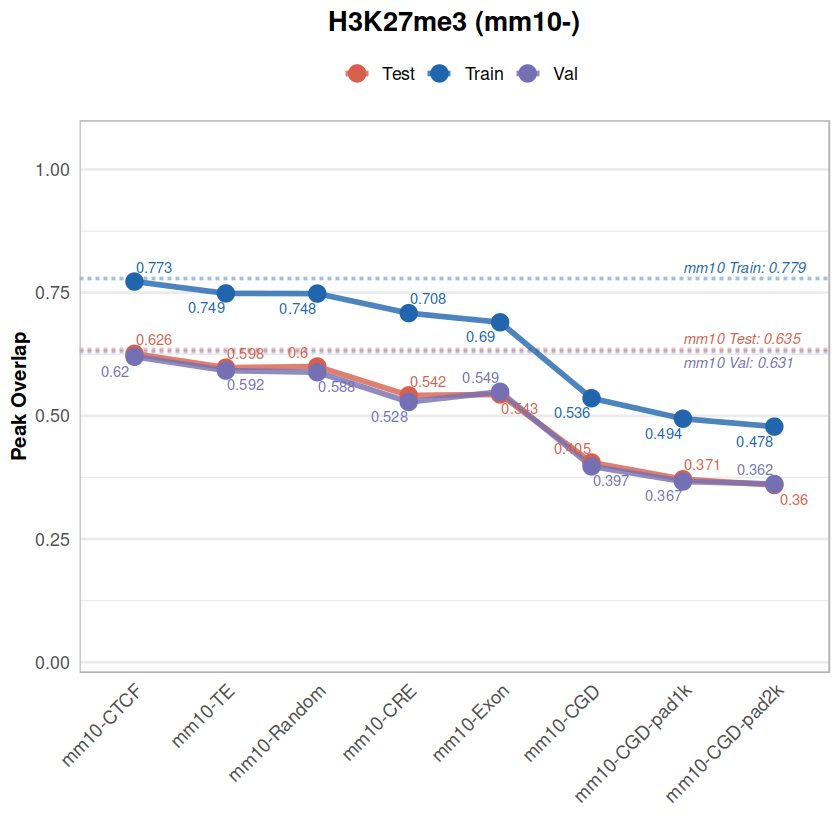

In [23]:
# ============================================================
# rf524k Overlap Plots
# ============================================================
# Using unified plot_performance() function with predefined LEVELS

# K27 overlap plots
p_overlap_k27_silplus <- plot_performance(
    overlap_k27, metric = "overlap", mark_label = "H3K27me3",
    series_filter = "silicusPlus", title_suffix = "(silicus+)",
    x_levels = LEVELS$silicus_plus, show_sns = FALSE, sns_data = overlap_sns
)
p_overlap_k27_siltelescope <- plot_performance(
    overlap_k27, metric = "overlap", mark_label = "H3K27me3",
    series_filter = "silicusTelescope", title_suffix = "(silicus telescope)",
    x_levels = LEVELS$silicus_telescope, show_sns = FALSE, sns_data = overlap_sns
)
p_overlap_k27_mm10minus <- plot_performance(
    overlap_k27, metric = "overlap", mark_label = "H3K27me3",
    series_filter = "mm10Minus", title_suffix = "(mm10-)",
    x_levels = LEVELS$mm10_minus, show_sns = FALSE, sns_data = overlap_sns
)

# K4 overlap plots
p_overlap_k4_silplus <- plot_performance(
    overlap_k4, metric = "overlap", mark_label = "H3K4me3",
    series_filter = "silicusPlus", title_suffix = "(silicus+)",
    x_levels = LEVELS$silicus_plus
)
p_overlap_k4_siltelescope <- plot_performance(
    overlap_k4, metric = "overlap", mark_label = "H3K4me3",
    series_filter = "silicusTelescope", title_suffix = "(silicus telescope)",
    x_levels = LEVELS$silicus_telescope
)
p_overlap_k4_mm10minus <- plot_performance(
    overlap_k4, metric = "overlap", mark_label = "H3K4me3",
    series_filter = "mm10Minus", title_suffix = "(mm10-)",
    x_levels = LEVELS$mm10_minus
)

sps(7, 7)
print(p_overlap_k27_silplus)
print(p_overlap_k27_siltelescope)
print(p_overlap_k27_mm10minus)

Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_line()`).”
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_line()`).”
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


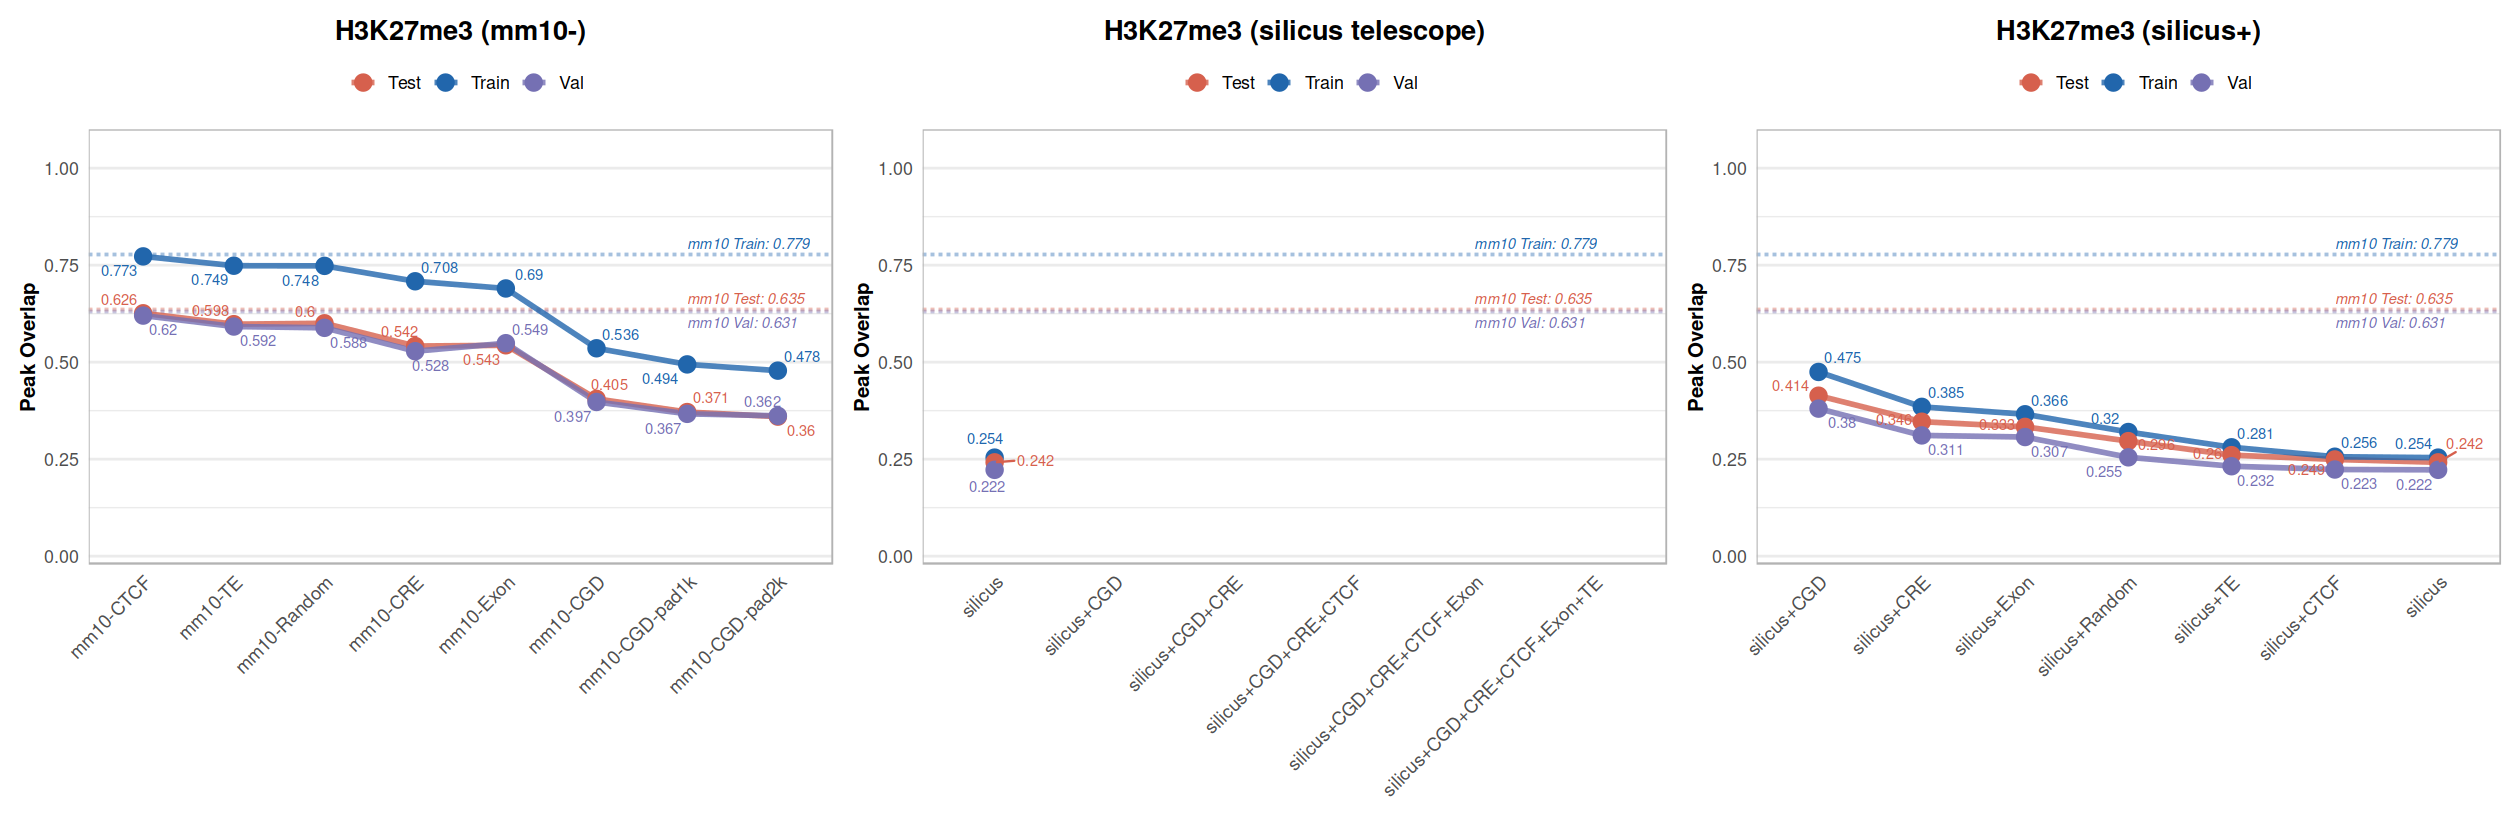

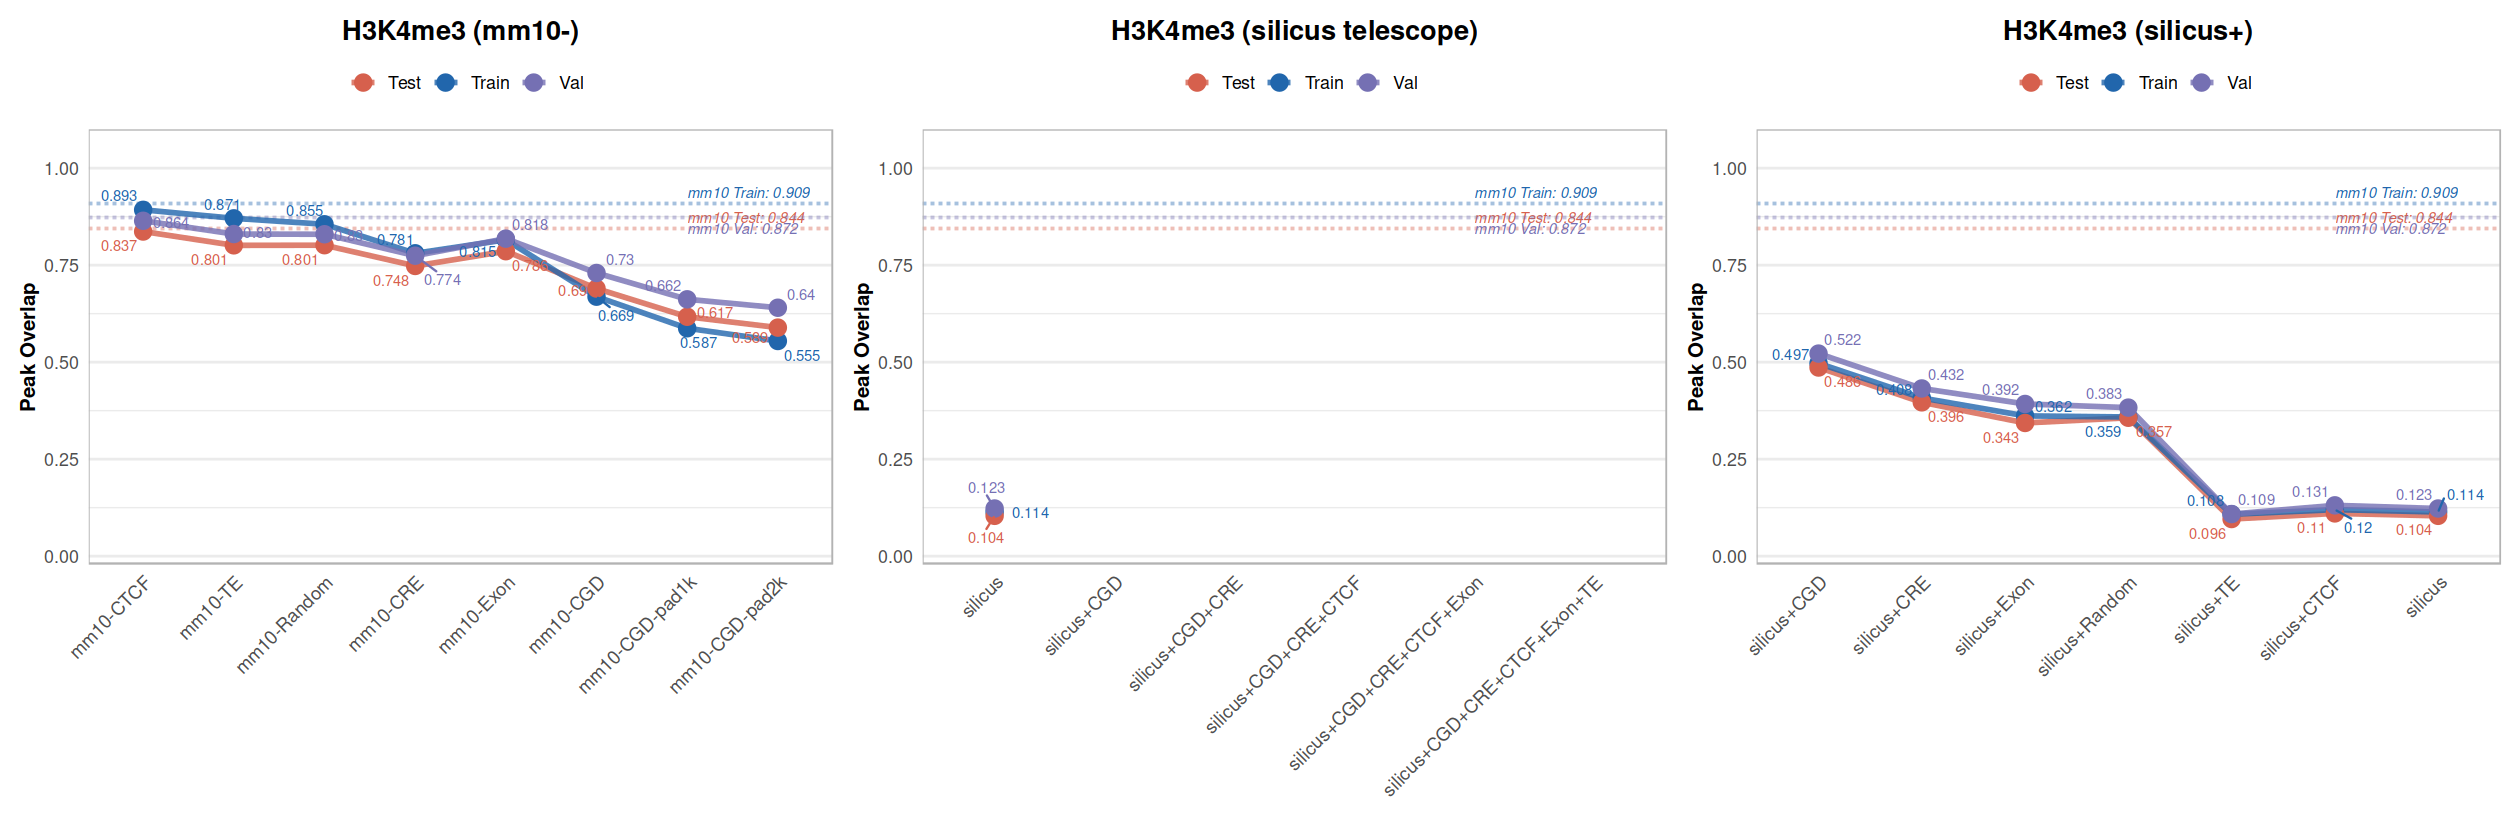

In [24]:
library(patchwork)

sps(21, 7)
p_overlap_k27_mm10minus + p_overlap_k27_siltelescope + p_overlap_k27_silplus
p_overlap_k4_mm10minus + p_overlap_k4_siltelescope + p_overlap_k4_silplus

In [ ]:
# Compute R^2 metrics using gcor

calc_rsqr_gcor <- function(pred_tracks, pred_cols, obs_track_expr, 
                           intervals, iterator_intervals) {
    track_pairs <- as.vector(rbind(pred_tracks, rep(obs_track_expr, length(pred_tracks))))
    cors <- do.call(gcor, c(
        as.list(track_pairs),
        list(intervals = intervals, iterator = iterator_intervals, names = pred_cols)
    ))
    return(cors)
}

# Note: intervals_train, intervals_test, intervals_val are created in the data loading cell
# using create_split_intervals(cg_trace_f)

message(sprintf("Using intervals: Train=%d, Test=%d, Val=%d", 
                nrow(intervals_train), nrow(intervals_test), nrow(intervals_val)))

k27_info <- track_tbl %>% filter(mark == "K27")
k4_info <- track_tbl %>% filter(mark == "K4")

message("Calculating R^2 for K27 tracks...")
cor_k27_train <- calc_rsqr_gcor(k27_info$track_name, k27_info$col_name, obs_k27_expr, intervals_train, intervals_train) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k27-train.rds")
cor_k27_test <- calc_rsqr_gcor(k27_info$track_name, k27_info$col_name, obs_k27_expr, intervals_test, intervals_test) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k27-test.rds")
cor_k27_val <- calc_rsqr_gcor(k27_info$track_name, k27_info$col_name, obs_k27_expr, intervals_val, intervals_val) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k27-val.rds")

message("Calculating R^2 for K4 tracks...")
cor_k4_train <- calc_rsqr_gcor(k4_info$track_name, k4_info$col_name, obs_k4_expr, intervals_train, intervals_train) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k4-train.rds")
cor_k4_test <- calc_rsqr_gcor(k4_info$track_name, k4_info$col_name, obs_k4_expr, intervals_test, intervals_test) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k4-test.rds")
cor_k4_val <- calc_rsqr_gcor(k4_info$track_name, k4_info$col_name, obs_k4_expr, intervals_val, intervals_val) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k4-val.rds")

rsqr_k27 <- data.frame(
    col_name = names(cor_k27_train),
    r2_train = cor_k27_train^2,
    r2_test = cor_k27_test^2,
    r2_val = cor_k27_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(track_tbl %>% select(col_name, genome_label, genome_dir, series, order), by = "col_name")

rsqr_k4 <- data.frame(
    col_name = names(cor_k4_train),
    r2_train = cor_k4_train^2,
    r2_test = cor_k4_test^2,
    r2_val = cor_k4_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(track_tbl %>% select(col_name, genome_label, genome_dir, series, order), by = "col_name")

# SNS R^2 (K27 only)
message("\nCalculating R^2 for SNS tracks (K27 only)...")
if (exists("sns_track_tbl") && all(sapply(sns_track_tbl$track_name, gtrack.exists))) {
    cor_sns_train <- calc_rsqr_gcor(sns_track_tbl$track_name, sns_track_tbl$col_name, obs_k27_expr, intervals_train, intervals_train) %cache_rds% file.path(CONFIG$output_dir, "rsqr-sns-train.rds")
    cor_sns_test <- calc_rsqr_gcor(sns_track_tbl$track_name, sns_track_tbl$col_name, obs_k27_expr, intervals_test, intervals_test) %cache_rds% file.path(CONFIG$output_dir, "rsqr-sns-test.rds")
    cor_sns_val <- calc_rsqr_gcor(sns_track_tbl$track_name, sns_track_tbl$col_name, obs_k27_expr, intervals_val, intervals_val) %cache_rds% file.path(CONFIG$output_dir, "rsqr-sns-val.rds")
    
    rsqr_sns <- data.frame(
        col_name = names(cor_sns_train),
        r2_train = cor_sns_train^2,
        r2_test = cor_sns_test^2,
        r2_val = cor_sns_val^2,
        stringsAsFactors = FALSE
    )
    message("\nSNS R^2 (K27):")
    print(rsqr_sns %>% select(col_name, r2_train, r2_test, r2_val))
} else {
    message("SNS tracks not found, skipping")
    rsqr_sns <- NULL
}

message("\nK27 R^2:")
print(rsqr_k27 %>% arrange(series, order) %>% select(genome_label, r2_train, r2_test, r2_val))

Using intervals: Train=6144130, Test=1720962, Val=884892

Calculating R^2 for K27 tracks...



recover called non-interactively; frames dumped, use debugger() to view


In [ ]:
# ============================================================
# rf524k R² Plots
# ============================================================
# Using unified plot_performance() function with predefined LEVELS

# K27 R^2 plots
p_rsqr_k27_silplus <- plot_performance(
    rsqr_k27, metric = "rsqr", mark_label = "H3K27me3",
    series_filter = "silicusPlus", title_suffix = "(silicus+)",
    x_levels = LEVELS$silicus_plus, show_sns = TRUE, sns_data = rsqr_sns
)
p_rsqr_k27_siltelescope <- plot_performance(
    rsqr_k27, metric = "rsqr", mark_label = "H3K27me3",
    series_filter = "silicusTelescope", title_suffix = "(telescope)",
    x_levels = LEVELS$silicus_telescope, show_sns = TRUE, sns_data = rsqr_sns
)
p_rsqr_k27_mm10minus <- plot_performance(
    rsqr_k27, metric = "rsqr", mark_label = "H3K27me3",
    series_filter = "mm10Minus", title_suffix = "(mm10-)",
    x_levels = LEVELS$mm10_minus, show_sns = TRUE, sns_data = rsqr_sns
)

# K4 R^2 plots
p_rsqr_k4_silplus <- plot_performance(
    rsqr_k4, metric = "rsqr", mark_label = "H3K4me3",
    series_filter = "silicusPlus", title_suffix = "(silicus+)",
    x_levels = LEVELS$silicus_plus
)
p_rsqr_k4_siltelescope <- plot_performance(
    rsqr_k4, metric = "rsqr", mark_label = "H3K4me3",
    series_filter = "silicusTelescope", title_suffix = "(telescope)",
    x_levels = LEVELS$silicus_telescope
)
p_rsqr_k4_mm10minus <- plot_performance(
    rsqr_k4, metric = "rsqr", mark_label = "H3K4me3",
    series_filter = "mm10Minus", title_suffix = "(mm10-)",
    x_levels = LEVELS$mm10_minus
)

sps(7, 7)
print(p_rsqr_k27_silplus)
print(p_rsqr_k27_siltelescope)
print(p_rsqr_k27_mm10minus)

Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


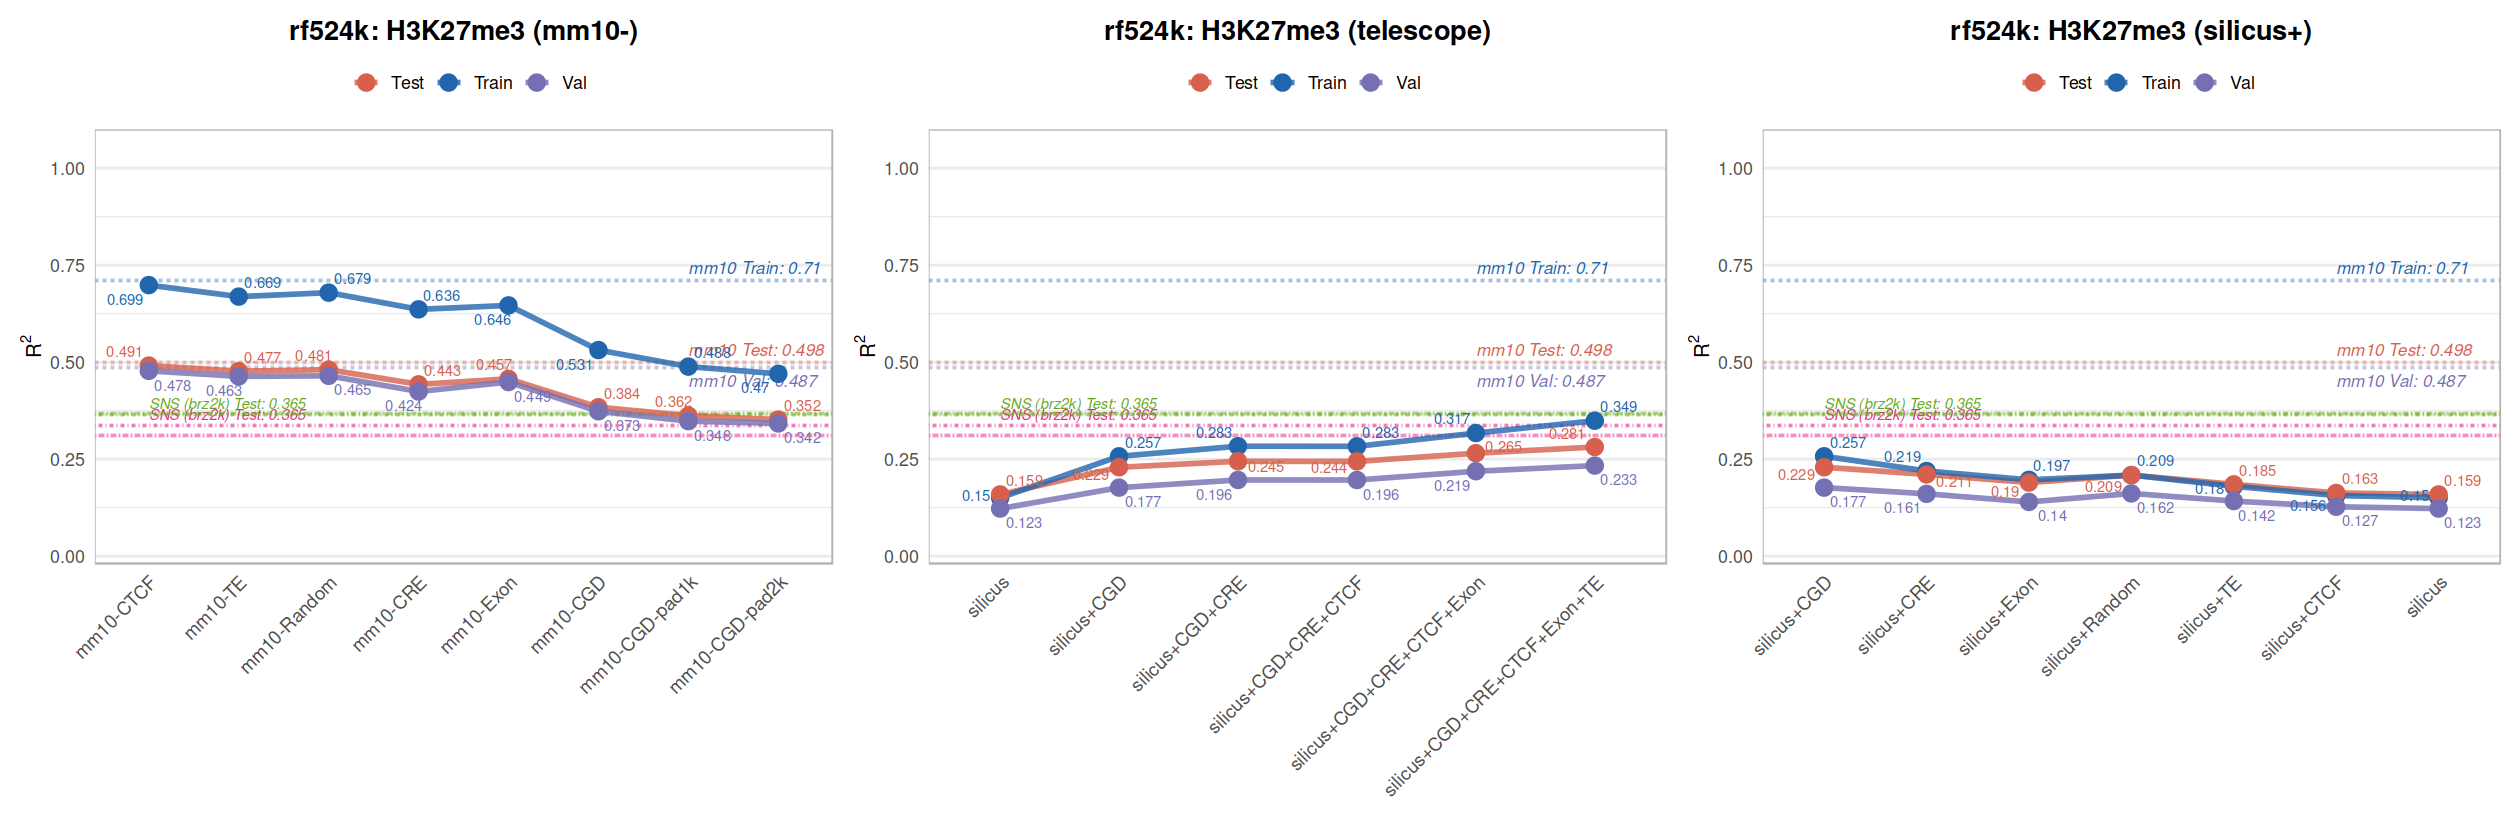

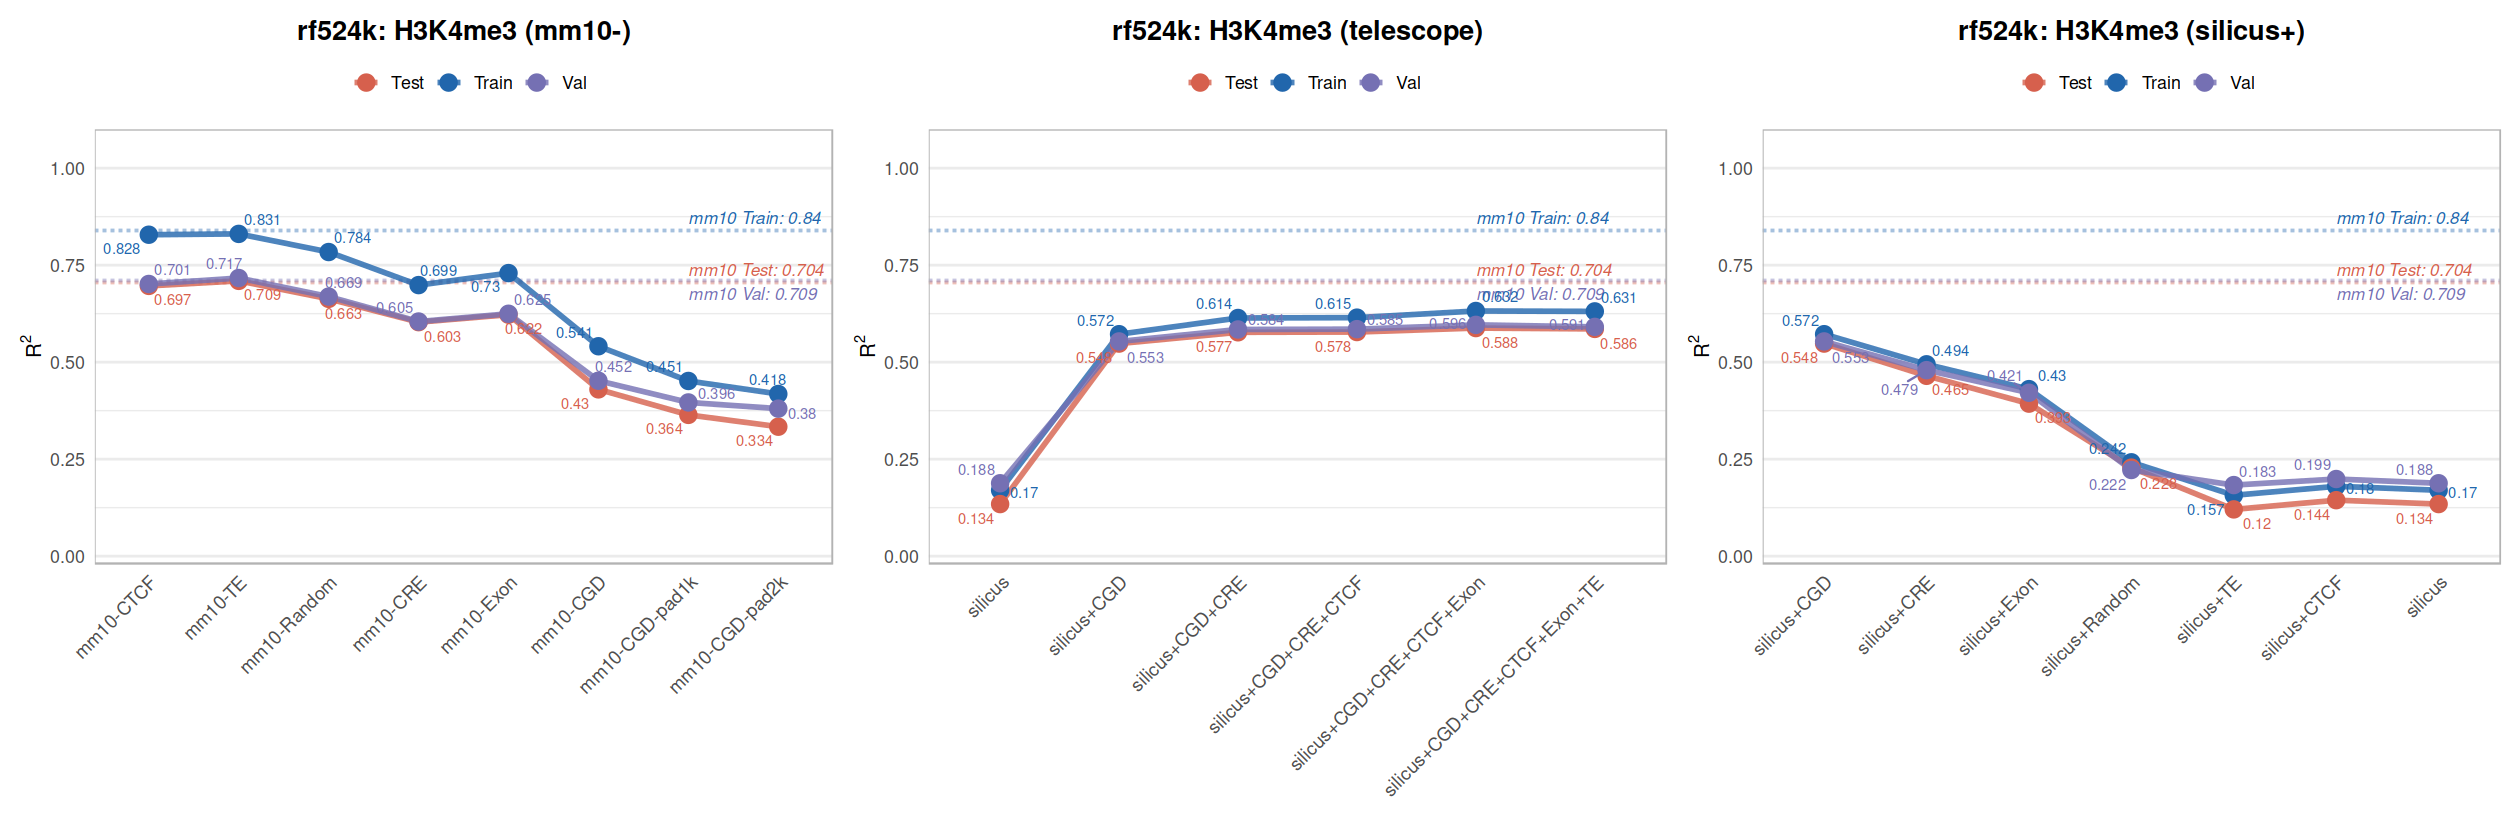

In [ ]:
sps(21, 7)
p_rsqr_k27_mm10minus + p_rsqr_k27_siltelescope + p_rsqr_k27_silplus
p_rsqr_k4_mm10minus + p_rsqr_k4_siltelescope + p_rsqr_k4_silplus

## Receptive field comparison

In [ ]:
# Build track table for receptive field comparison
# Tracks: seq.IQ.pcg.flashzoi.mm10.rf* (pre-training) and seq.IQ.pcg.fm.mm10.rf* (foundation model)

rf_values <- c("1k", "2k", "4k", "8k", "16k", "32k", "64k", "128k", "256k", "524k")
rf_numeric <- c(1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288)

build_rf_comparison_track_table <- function() {
    # Flashzoi mm10 RF tracks (pre-training from scratch)
    flashzoi_k27 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "flashzoi",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.flashzoi.mm10.rf", rf, "_EB4_cnt"),
        col_name = paste0("flashzoi_rf", rf, "_k27"),
        mark = "K27"
    )
    
    flashzoi_k4 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "flashzoi",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.flashzoi.mm10.rf", rf, "_EB4_cnt_k4"),
        col_name = paste0("flashzoi_rf", rf, "_k4"),
        mark = "K4"
    )
    
    # Foundation model tracks - base mm10 RF series
    fm_k27 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "fm",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.fm.mm10.rf", rf, "_EB4_cnt"),
        col_name = paste0("fm_rf", rf, "_k27"),
        mark = "K27"
    )
    
    fm_k4 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "fm",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.fm.mm10.rf", rf, "_EB4_cnt_k4"),
        col_name = paste0("fm_rf", rf, "_k4"),
        mark = "K4"
    )
    
    # Combine all tracks
    track_tbl <- bind_rows(flashzoi_k27, flashzoi_k4, fm_k27, fm_k4)
    
    return(track_tbl)
}

rf_track_tbl <- build_rf_comparison_track_table()

# Verify tracks exist
missing_tracks <- rf_track_tbl$track_name[!sapply(rf_track_tbl$track_name, gtrack.exists)]
if (length(missing_tracks) > 0) {
    message("WARNING: Missing tracks:")
    print(unique(missing_tracks))
} else {
    message(sprintf("All %d RF comparison tracks found!", nrow(rf_track_tbl)))
}

# Display track table summary
rf_track_tbl %>%
    group_by(series, mark) %>%
    summarise(n_tracks = n(), .groups = "drop") %>%
    print()

All 40 RF comparison tracks found!



# A tibble: 4 x 3
    series mark n_tracks
1 flashzoi  K27       10
2 flashzoi   K4       10
3       fm  K27       10
4       fm   K4       10


In [ ]:
# Compute peak overlap metrics for RF comparison tracks
# Uses compute_all_track_peak_overlaps from borzoi_utils.R

rf_k27_tracks <- rf_track_tbl %>% filter(mark == "K27")
rf_k4_tracks <- rf_track_tbl %>% filter(mark == "K4")

message("Computing peak overlap for RF comparison K27 tracks...")
overlap_rf_k27 <- compute_all_track_peak_overlaps(
    track_tbl = rf_k27_tracks,
    obs_track_name = "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm",
    context_size = 200,
    T_q = 0.98,
    test_chroms = test_chroms,
    val_chroms = val_chroms,
    iterator_size = 100,
    n_cores = 50
) %cache_rds% here("output/borzoi-stats/overlap-rf-k27.rds")

message("\nComputing peak overlap for RF comparison K4 tracks...")
overlap_rf_k4 <- compute_all_track_peak_overlaps(
    track_tbl = rf_k4_tracks,
    obs_track_name = "jk.epipcg.pcg.CRJK_0411_k4me3_wt_to_wt_eb_d3",
    context_size = 200,
    T_q = 0.98,
    test_chroms = test_chroms,
    val_chroms = val_chroms,
    iterator_size = 100,
    n_cores = 50
) %cache_rds% here("output/borzoi-stats/overlap-rf-k4.rds")

message("\nRF Overlap calculation complete!")
message("\nK27 RF Overlap summary:")
print(overlap_rf_k27 %>% group_by(series) %>% summarise(n = n(), .groups = "drop"))
message("\nK4 RF Overlap summary:")
print(overlap_rf_k4 %>% group_by(series) %>% summarise(n = n(), .groups = "drop"))

Computing peak overlap for RF comparison K27 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/overlap-rf-k27.rds'


Computing peak overlap for RF comparison K4 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/overlap-rf-k4.rds'


RF Overlap calculation complete!


K27 RF Overlap summary:



# A tibble: 2 x 2
    series  n
1 flashzoi 10
2       fm 10



K4 RF Overlap summary:



# A tibble: 2 x 2
    series  n
1 flashzoi 10
2       fm 10


In [ ]:
# Compute R^2 metrics for RF comparison tracks
# Uses calc_rsqr_gcor function defined in Cell 9

rf_k27_info <- rf_track_tbl %>% filter(mark == "K27")
rf_k4_info <- rf_track_tbl %>% filter(mark == "K4")

obs_k27_expr <- "log2(1 + jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm)"
obs_k4_expr <- "log2(1 + jk.epipcg.pcg.CRJK_0411_k4me3_wt_to_wt_eb_d3)"

message("Calculating R^2 for RF comparison K27 tracks...")
cor_rf_k27_train <- calc_rsqr_gcor(rf_k27_info$track_name, rf_k27_info$col_name, obs_k27_expr, intervals_train, intervals_train) %cache_rds% here("output/borzoi-stats/rsqr-rf-k27-train.rds")
cor_rf_k27_test <- calc_rsqr_gcor(rf_k27_info$track_name, rf_k27_info$col_name, obs_k27_expr, intervals_test, intervals_test) %cache_rds% here("output/borzoi-stats/rsqr-rf-k27-test.rds")
cor_rf_k27_val <- calc_rsqr_gcor(rf_k27_info$track_name, rf_k27_info$col_name, obs_k27_expr, intervals_val, intervals_val) %cache_rds% here("output/borzoi-stats/rsqr-rf-k27-val.rds")

message("Calculating R^2 for RF comparison K4 tracks...")
cor_rf_k4_train <- calc_rsqr_gcor(rf_k4_info$track_name, rf_k4_info$col_name, obs_k4_expr, intervals_train, intervals_train) %cache_rds% here("output/borzoi-stats/rsqr-rf-k4-train.rds")
cor_rf_k4_test <- calc_rsqr_gcor(rf_k4_info$track_name, rf_k4_info$col_name, obs_k4_expr, intervals_test, intervals_test) %cache_rds% here("output/borzoi-stats/rsqr-rf-k4-test.rds")
cor_rf_k4_val <- calc_rsqr_gcor(rf_k4_info$track_name, rf_k4_info$col_name, obs_k4_expr, intervals_val, intervals_val) %cache_rds% here("output/borzoi-stats/rsqr-rf-k4-val.rds")

rsqr_rf_k27 <- data.frame(
    col_name = names(cor_rf_k27_train),
    r2_train = cor_rf_k27_train^2,
    r2_test = cor_rf_k27_test^2,
    r2_val = cor_rf_k27_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(rf_track_tbl %>% filter(mark == "K27") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")

rsqr_rf_k4 <- data.frame(
    col_name = names(cor_rf_k4_train),
    r2_train = cor_rf_k4_train^2,
    r2_test = cor_rf_k4_test^2,
    r2_val = cor_rf_k4_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(rf_track_tbl %>% filter(mark == "K4") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")

message("\nRF R^2 calculation complete!")
message("\nK27 RF R^2 summary:")
print(rsqr_rf_k27 %>% group_by(series) %>% summarise(n = n(), mean_test_r2 = mean(r2_test), .groups = "drop"))
message("\nK4 RF R^2 summary:")
print(rsqr_rf_k4 %>% group_by(series) %>% summarise(n = n(), mean_test_r2 = mean(r2_test), .groups = "drop"))

Calculating R^2 for RF comparison K27 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k27-train.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k27-test.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k27-val.rds'

Calculating R^2 for RF comparison K4 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k4-train.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k4-test.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-sta

# A tibble: 2 x 3
    series  n mean_test_r2
1 flashzoi 10    0.3953888
2       fm 10    0.4490851



K4 RF R^2 summary:



# A tibble: 2 x 3
    series  n mean_test_r2
1 flashzoi 10    0.6828738
2       fm 10    0.6948170


In [ ]:
#' Plot RF comparison overlap with RF values on x-axis
#'
#' @param overlap_data Main overlap data frame with train_p, test_p, val_p columns and rf_numeric
#' @param mark_label Label for the histone mark (e.g., "H3K27me3")
#' @param series_name Series to filter (e.g., "flashzoi", "fm")
#' @param title_suffix Suffix for the plot title
#' @param show_val Whether to show validation chromosome data (default TRUE)
plot_rf_comparison_overlap <- function(overlap_data, mark_label, series_name, title_suffix = "", 
                                       show_val = TRUE, point_size = 4, text_size = 3, line_width = 1.2, max.overlaps = 20) {
    plot_data <- overlap_data %>%
        filter(series == series_name) %>%
        arrange(rf_numeric)
    
    cols_to_pivot <- c("train_p", "test_p")
    name_map <- c(train_p = "Train", test_p = "Test")
    
    if (show_val) {
        cols_to_pivot <- c(cols_to_pivot, "val_p")
        name_map <- c(name_map, val_p = "Val")
    }
    
    plot_df <- plot_data %>%
        pivot_longer(cols = all_of(cols_to_pivot), 
                     names_to = "dataset", 
                     values_to = "overlap") %>%
        mutate(dataset = name_map[dataset])
    
    p <- ggplot(plot_df, aes(x = rf_numeric, y = overlap, color = dataset, group = dataset)) +
        geom_line(linewidth = line_width, alpha = 0.8) +
        geom_point(size = point_size) +
        geom_text_repel(
            aes(label = round(overlap, 3)),
            size = text_size,
            max.overlaps = max.overlaps,
            box.padding = 0.3,
            show.legend = FALSE
        ) +
        scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
        scale_x_continuous(
            breaks = rf_numeric,
            labels = rf_values,
            trans = "log10"
        ) +
        scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0.02, 0.1))) +
        labs(
            title = paste0(mark_label, " ", title_suffix),
            x = "Receptive Field",
            y = "Peak Overlap",
            color = ""
        ) +
        theme_minimal(base_size = 13) +
        theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
            axis.text.x = element_text(angle = 90, hjust = 1, size = 11),
            axis.title = element_text(size = 12, face = "bold"),
            legend.position = "top",
            panel.grid.major.x = element_blank(),
            panel.border = element_rect(color = "gray70", fill = NA, linewidth = 0.5)
        )
    
    return(p)
}

#' Plot RF comparison R^2 with RF values on x-axis
#'
#' @param rsqr_data Main rsqr data frame with r2_train, r2_test, r2_val columns and rf_numeric
#' @param mark_label Label for the histone mark (e.g., "H3K27me3")
#' @param series_name Series to filter (e.g., "flashzoi", "fm")
#' @param title_suffix Suffix for the plot title
#' @param show_val Whether to show validation chromosome data (default TRUE)
plot_rf_comparison_rsqr <- function(rsqr_data, mark_label, series_name, title_suffix = "", 
                                    show_val = TRUE, point_size = 4, text_size = 3, line_width = 1.2, max.overlaps = 20) {
    plot_data <- rsqr_data %>%
        filter(series == series_name) %>%
        arrange(rf_numeric)
    
    cols_to_pivot <- c("r2_train", "r2_test")
    name_map <- c(r2_train = "Train", r2_test = "Test")
    
    if (show_val) {
        cols_to_pivot <- c(cols_to_pivot, "r2_val")
        name_map <- c(name_map, r2_val = "Val")
    }
    
    plot_df <- plot_data %>%
        pivot_longer(cols = all_of(cols_to_pivot), 
                     names_to = "dataset", 
                     values_to = "r2") %>%
        mutate(dataset = name_map[dataset])
    
    p <- ggplot(plot_df, aes(x = rf_numeric, y = r2, color = dataset, group = dataset)) +
        geom_line(linewidth = line_width, alpha = 0.8) +
        geom_point(size = point_size) +
        geom_text_repel(
            aes(label = round(r2, 3)),
            size = text_size,
            max.overlaps = max.overlaps,
            box.padding = 0.3,
            show.legend = FALSE
        ) +
        scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
        scale_x_continuous(
            breaks = rf_numeric,
            labels = rf_values,
            trans = "log10"
        ) +
        scale_y_continuous(expand = expansion(mult = c(0.02, 0.1))) +
        labs(
            title = paste0(mark_label, " ", title_suffix),
            x = "Receptive Field",
            y = expression(R^2),
            color = ""
        ) +
        theme_minimal(base_size = 13) +
        theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
            axis.text.x = element_text(angle = 90, hjust = 1, size = 11),
            axis.title = element_text(size = 12, face = "bold"),
            legend.position = "top",
            panel.grid.major.x = element_blank(),
            panel.border = element_rect(color = "gray70", fill = NA, linewidth = 0.5)
        )
    
    return(p)
}

In [ ]:
p <- plot_rf_comparison_overlap(overlap_rf_k27, "H3K27me3", "fm", "(Foundation Model)", show_val = FALSE, text_size = 2, point_size = 1, line_width = 0.5, max.overlaps = 2) + ylim(0, 0.75) + ggtitle("") + tgppt::theme_arial(7) + vertical_labs()
tgppt::plot_gg_ppt(p, here("figures/rf-comparison-k27-fm.pptx"), width = 6, height = 4, sep_legend = TRUE, overwrite = TRUE)
p_r2 <- plot_rf_comparison_rsqr(rsqr_rf_k27, "H3K27me3", "fm", "(Foundation Model)", show_val = FALSE, text_size = 2, point_size = 1, line_width = 0.5, max.overlaps = 2) + ylim(0, 0.75) + ggtitle("") + tgppt::theme_arial(7) + vertical_labs()
tgppt::plot_gg_ppt(p_r2, here("figures/rf-comparison-k27-fm.pptx"), width = 6, height = 4, sep_legend = TRUE, overwrite = FALSE, top = 15)
# p
# p_rf_overlap_k27_flashzoi

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [ ]:
p <- plot_rf_comparison_overlap(overlap_rf_k27, "H3K27me3", "flashzoi", "(Pre-training)", show_val = FALSE, text_size = 2, point_size = 1, line_width = 0.5, max.overlaps = 2) + ylim(0, 0.8) + ggtitle("") + tgppt::theme_arial(7) + vertical_labs()
tgppt::plot_gg_ppt(p, here("figures/rf-comparison-k27-pt.pptx"), width = 6, height = 4, sep_legend = TRUE, overwrite = TRUE)
p_r2 <- plot_rf_comparison_rsqr(rsqr_rf_k27, "H3K27me3", "flashzoi", "(Pre-training)", show_val = FALSE, text_size = 2, point_size = 1, line_width = 0.5, max.overlaps = 2) + ylim(0, 0.8) + ggtitle("") + tgppt::theme_arial(7) + vertical_labs()
tgppt::plot_gg_ppt(p_r2, here("figures/rf-comparison-k27-pt.pptx"), width = 6, height = 4, sep_legend = TRUE, overwrite = FALSE, top = 15)
# p
# p_rf_overlap_k27_flashzoi

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“ggrepel: 19 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


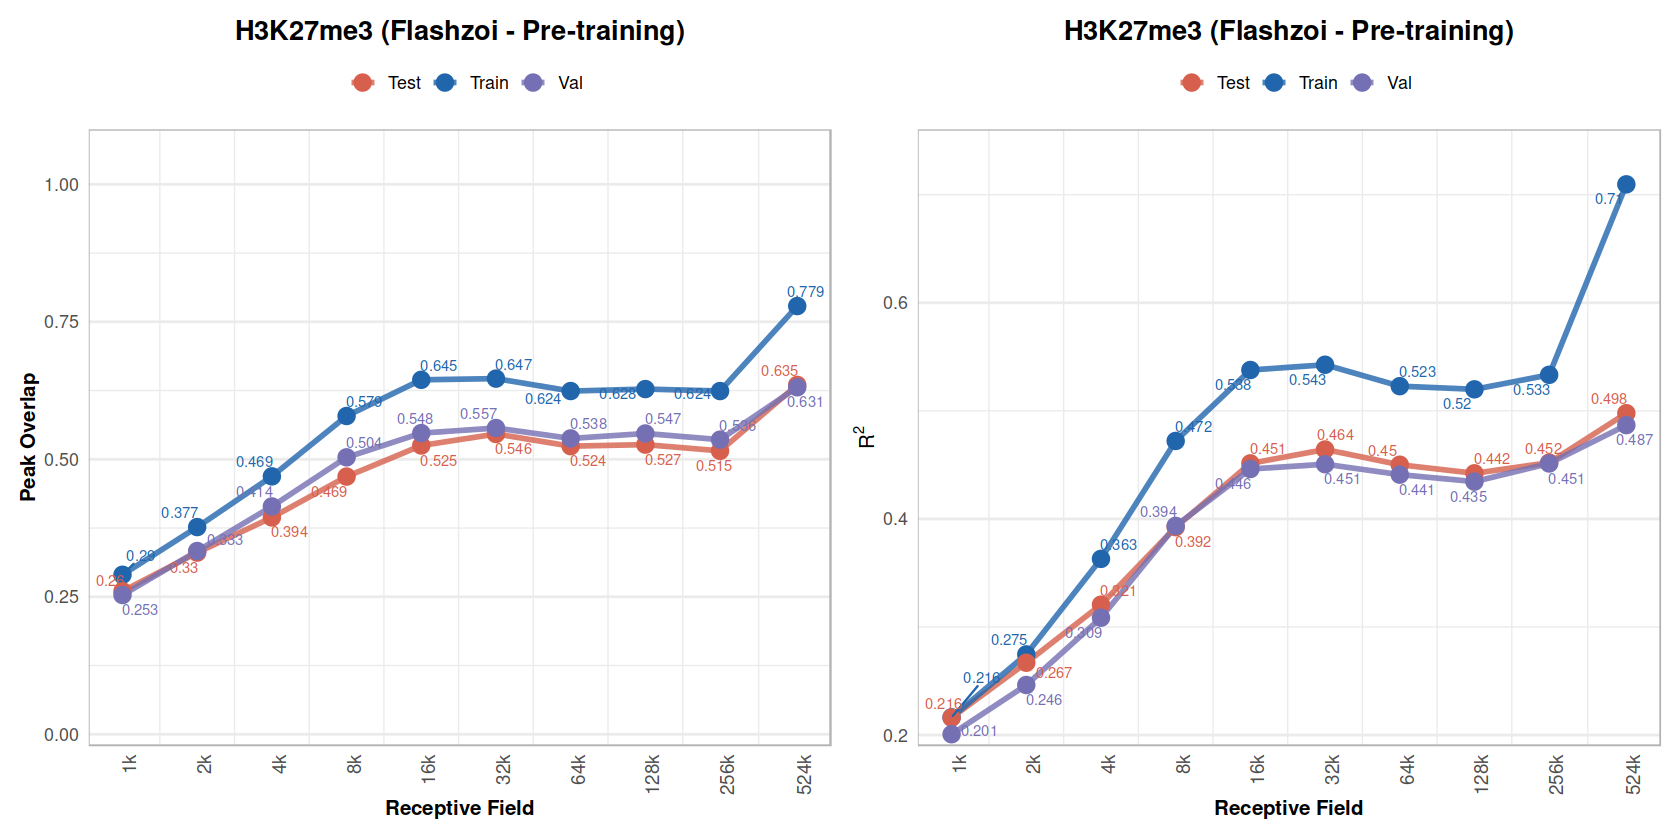

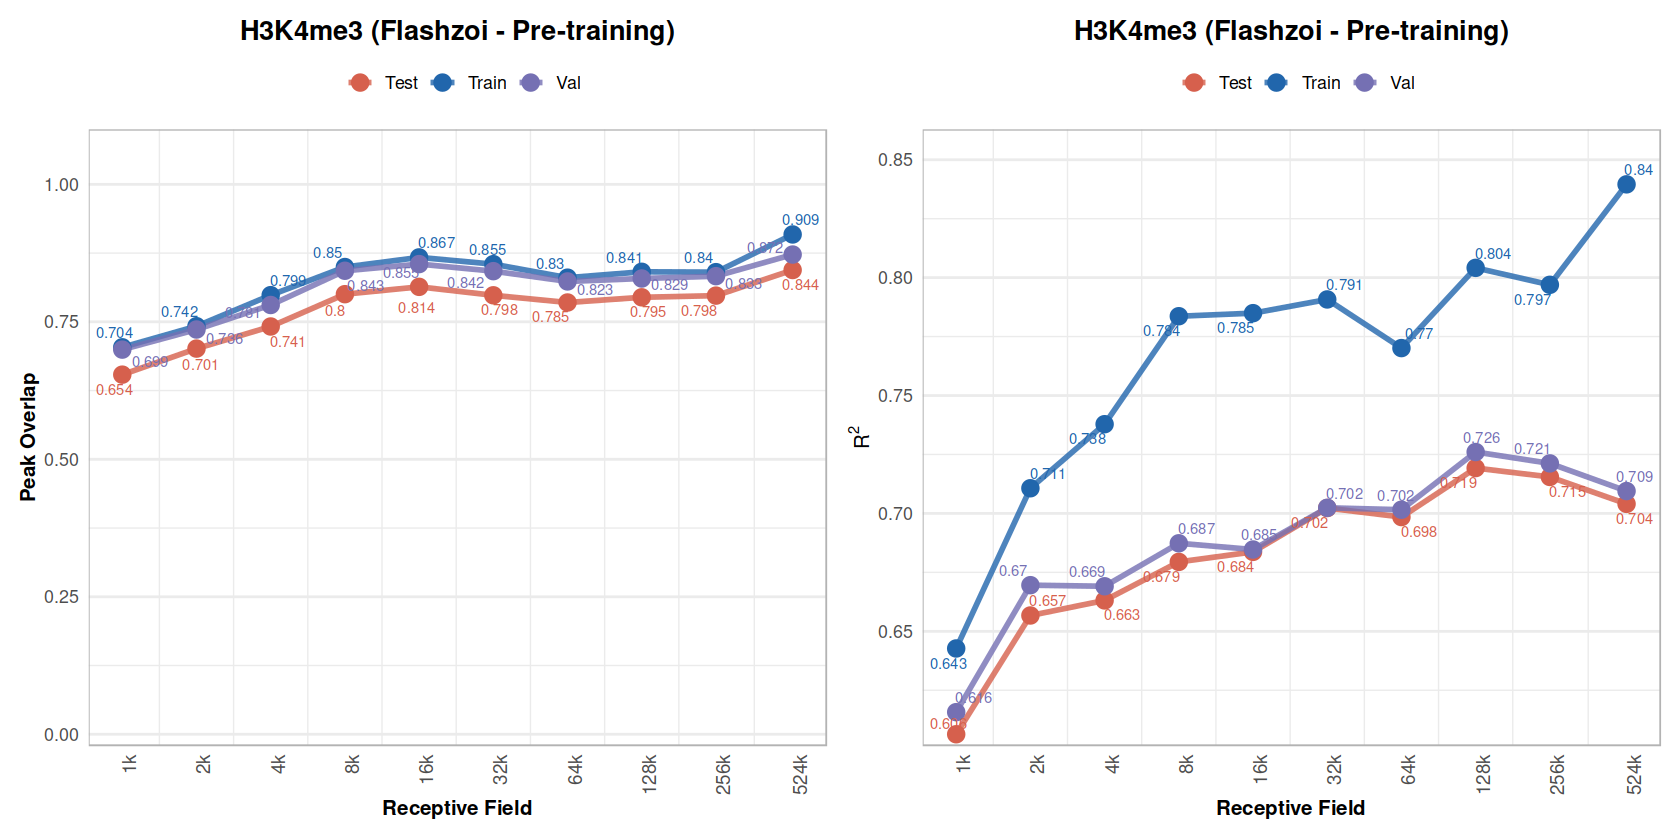

In [ ]:
# Create RF comparison plots - Flashzoi (Pre-training from scratch)

# K27 overlap and rsqr plots
p_rf_overlap_k27_flashzoi <- plot_rf_comparison_overlap(overlap_rf_k27, "H3K27me3", "flashzoi", "(Flashzoi - Pre-training)")
p_rf_rsqr_k27_flashzoi <- plot_rf_comparison_rsqr(rsqr_rf_k27, "H3K27me3", "flashzoi", "(Flashzoi - Pre-training)")

# K4 overlap and rsqr plots
p_rf_overlap_k4_flashzoi <- plot_rf_comparison_overlap(overlap_rf_k4, "H3K4me3", "flashzoi", "(Flashzoi - Pre-training)")
p_rf_rsqr_k4_flashzoi <- plot_rf_comparison_rsqr(rsqr_rf_k4, "H3K4me3", "flashzoi", "(Flashzoi - Pre-training)")

sps(14, 7)
print(p_rf_overlap_k27_flashzoi + p_rf_rsqr_k27_flashzoi)
print(p_rf_overlap_k4_flashzoi + p_rf_rsqr_k4_flashzoi)

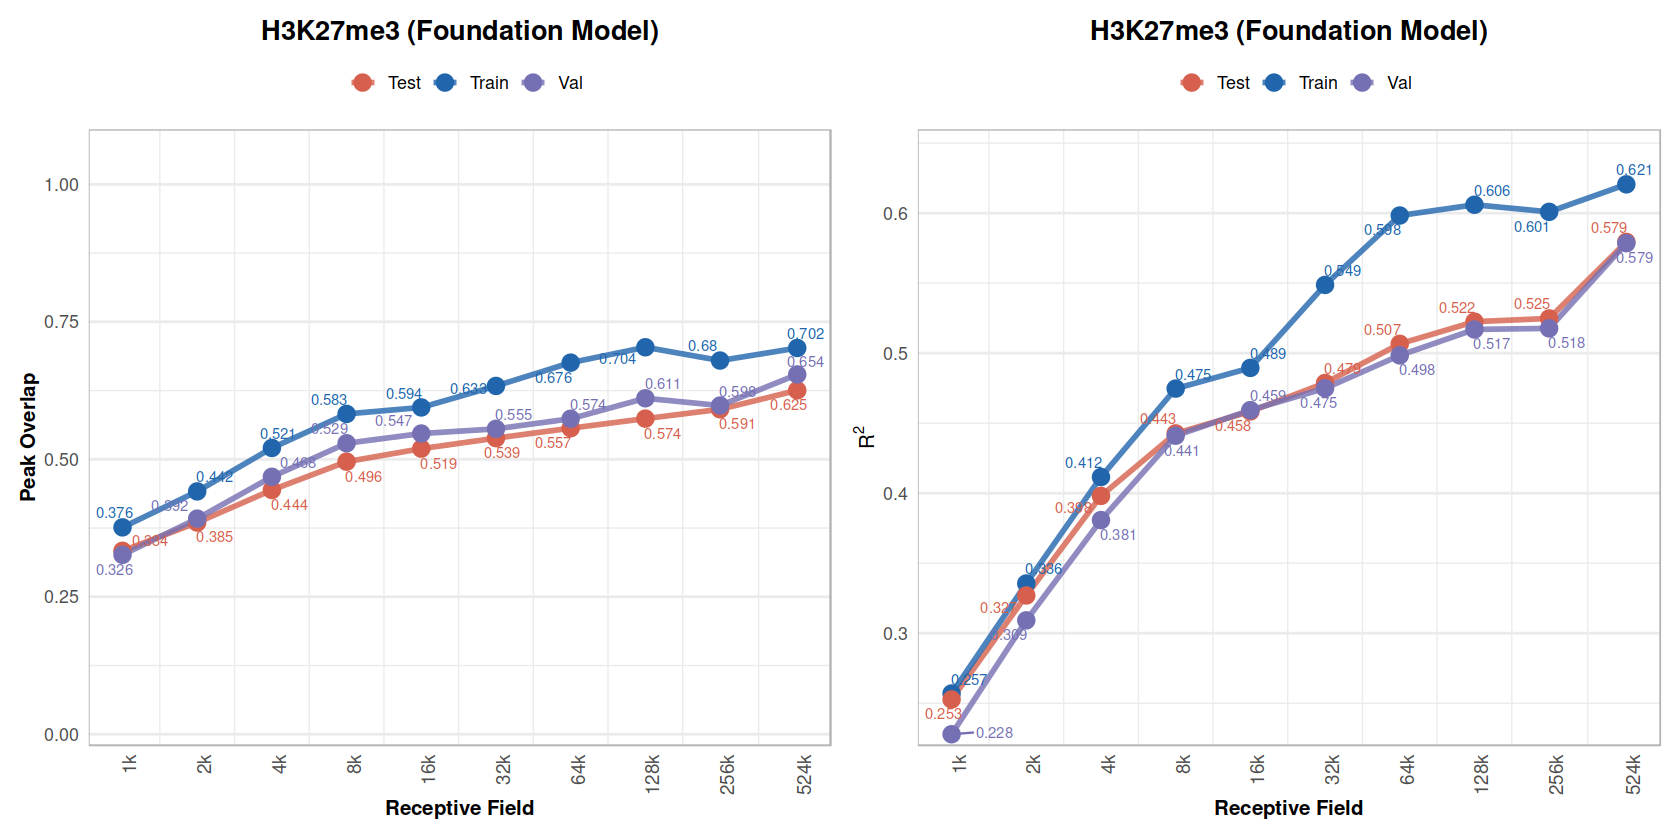

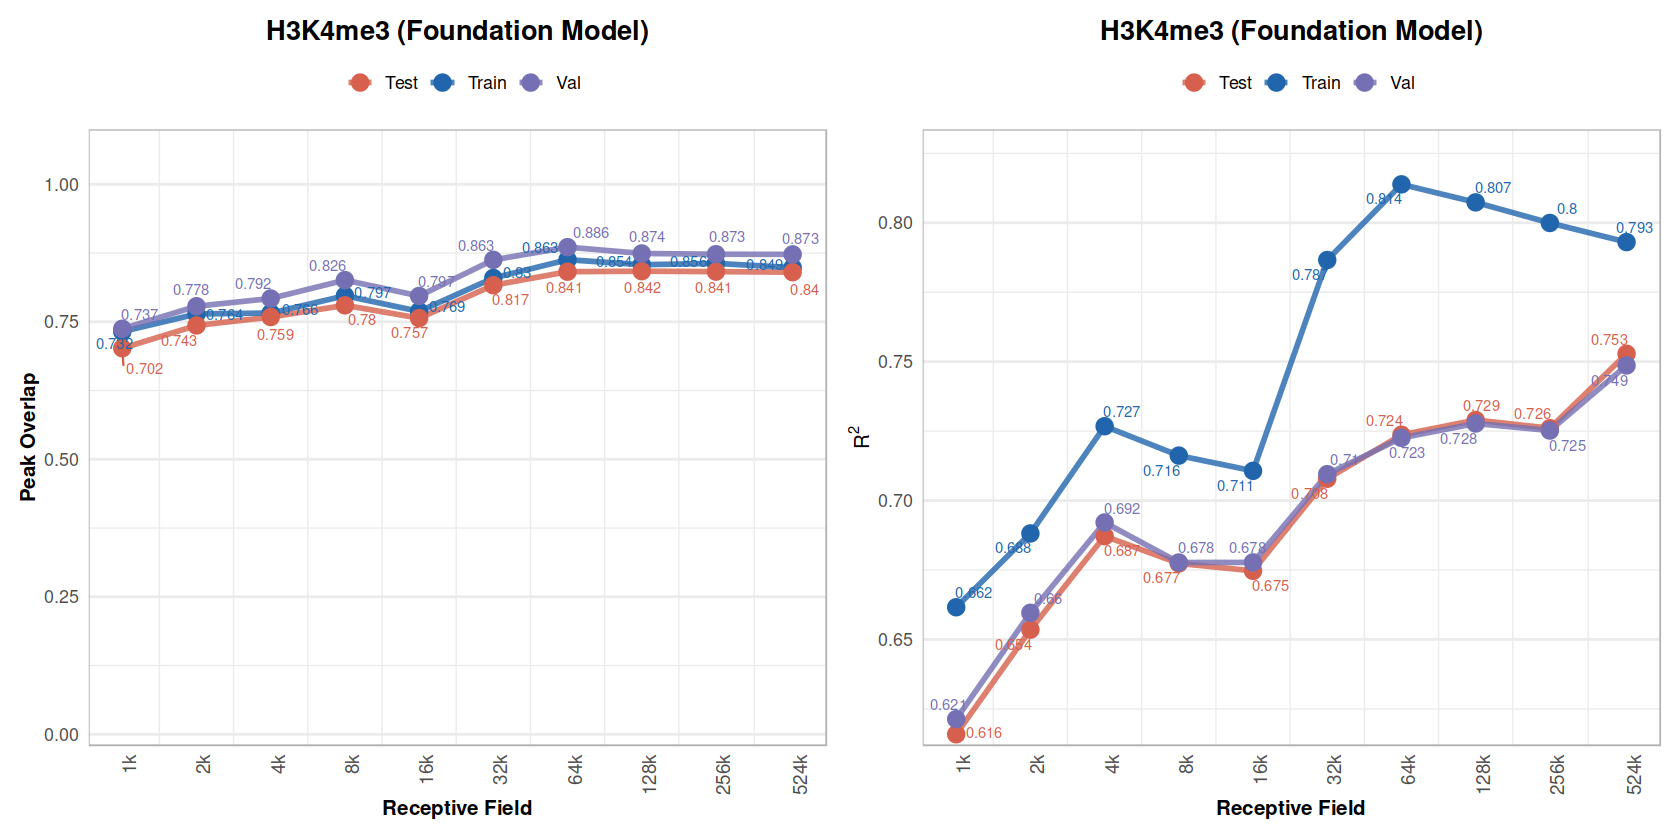

In [ ]:
# Create RF comparison plots - Foundation Model

# K27 overlap and rsqr plots
p_rf_overlap_k27_fm <- plot_rf_comparison_overlap(overlap_rf_k27, "H3K27me3", "fm", "(Foundation Model)")
p_rf_rsqr_k27_fm <- plot_rf_comparison_rsqr(rsqr_rf_k27, "H3K27me3", "fm", "(Foundation Model)")

# K4 overlap and rsqr plots
p_rf_overlap_k4_fm <- plot_rf_comparison_overlap(overlap_rf_k4, "H3K4me3", "fm", "(Foundation Model)")
p_rf_rsqr_k4_fm <- plot_rf_comparison_rsqr(rsqr_rf_k4, "H3K4me3", "fm", "(Foundation Model)")

sps(14, 7)
print(p_rf_overlap_k27_fm + p_rf_rsqr_k27_fm)
print(p_rf_overlap_k4_fm + p_rf_rsqr_k4_fm)

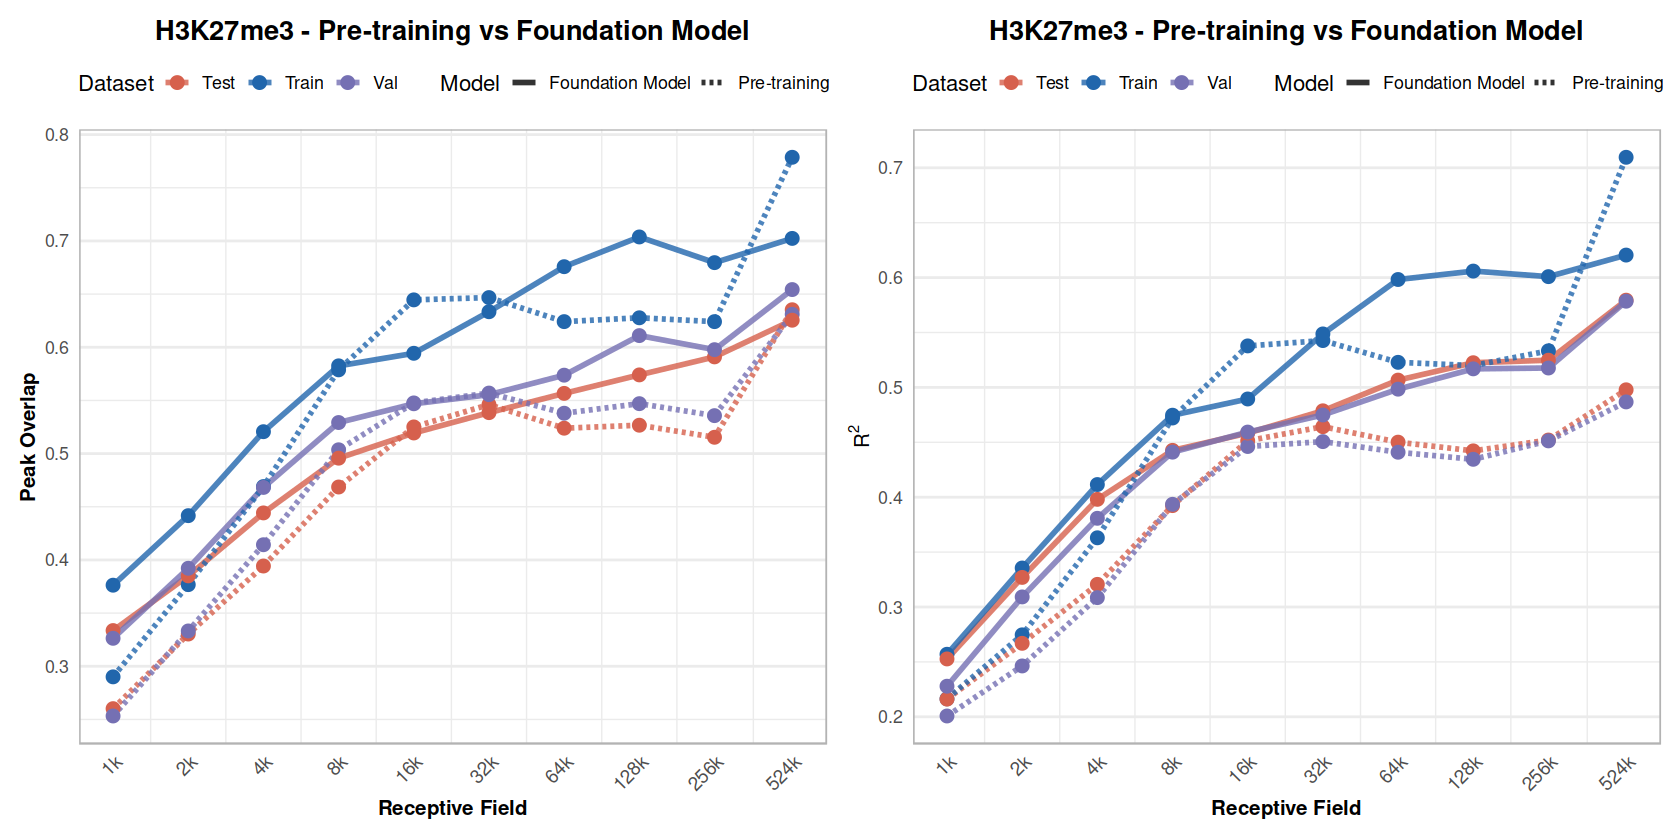

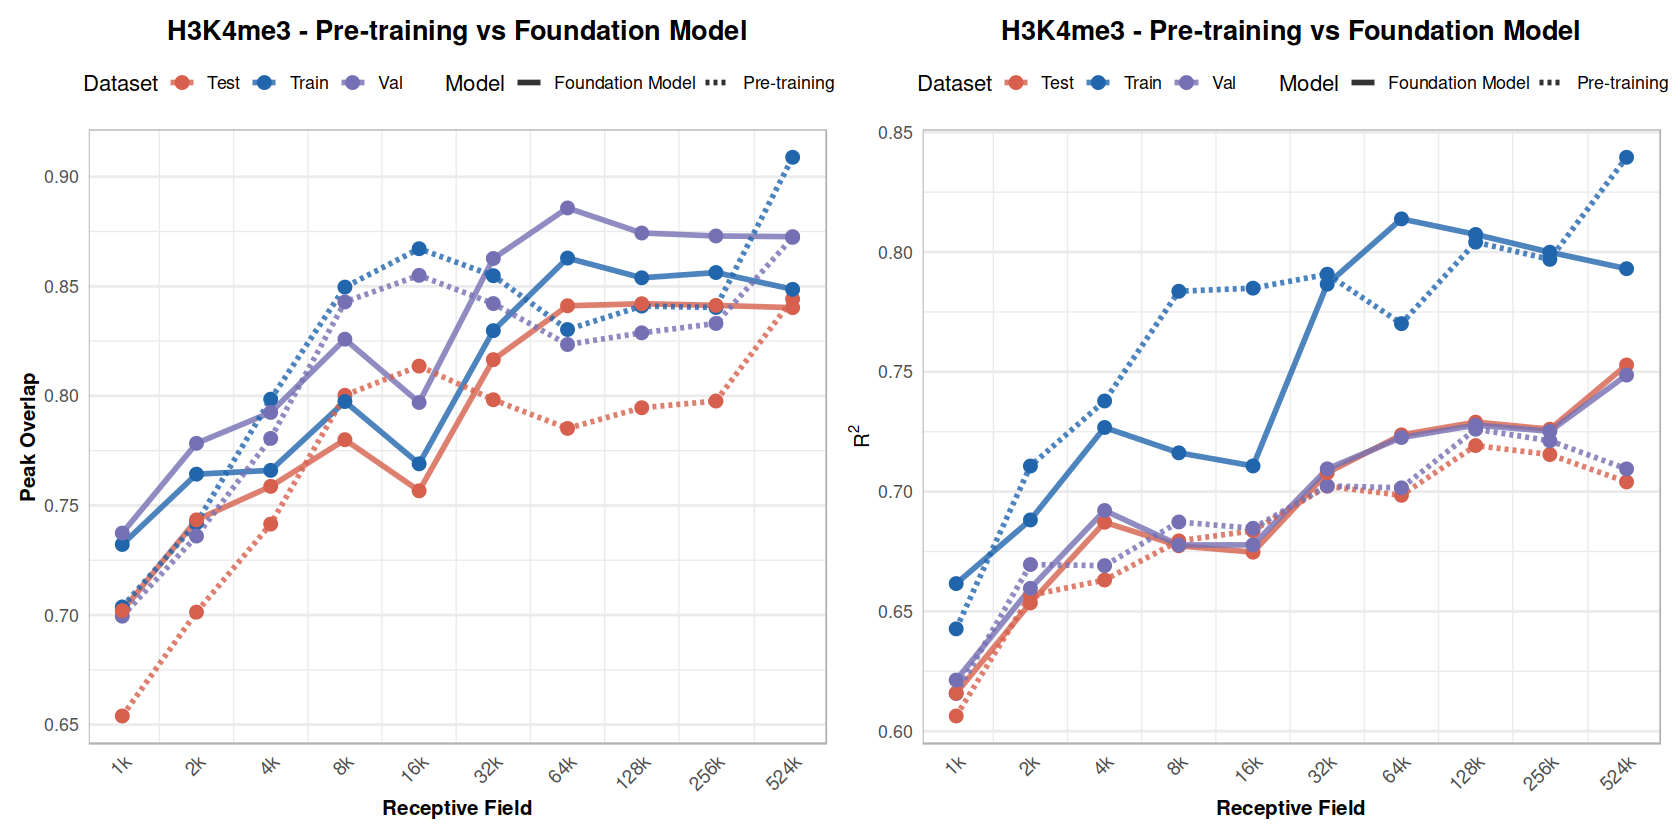

In [ ]:
# Combined RF comparison plot - Flashzoi vs Foundation Model

# Function to plot both series on same axes for comparison
plot_rf_comparison_combined <- function(data, mark_label, metric = "overlap", show_val = TRUE) {
    if (metric == "overlap") {
        cols_to_pivot <- c("train_p", "test_p")
        name_map <- c(train_p = "Train", test_p = "Test")
        if (show_val) {
            cols_to_pivot <- c(cols_to_pivot, "val_p")
            name_map <- c(name_map, val_p = "Val")
        }
        y_col <- "overlap"
        y_label <- "Peak Overlap"
    } else {
        cols_to_pivot <- c("r2_train", "r2_test")
        name_map <- c(r2_train = "Train", r2_test = "Test")
        if (show_val) {
            cols_to_pivot <- c(cols_to_pivot, "r2_val")
            name_map <- c(name_map, r2_val = "Val")
        }
        y_col <- "r2"
        y_label <- expression(R^2)
    }
    
    plot_df <- data %>%
        arrange(rf_numeric) %>%
        pivot_longer(cols = all_of(cols_to_pivot), 
                     names_to = "dataset", 
                     values_to = y_col) %>%
        mutate(
            dataset = name_map[dataset],
            series_label = if_else(series == "flashzoi", "Pre-training", "Foundation Model"),
            group_label = paste(series_label, dataset)
        )
    
    p <- ggplot(plot_df, aes(x = rf_numeric, y = .data[[y_col]], 
                              color = dataset, linetype = series_label, group = group_label)) +
        geom_line(linewidth = 1.2, alpha = 0.8) +
        geom_point(size = 3) +
        scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
        scale_linetype_manual(values = c("Pre-training" = "dashed", "Foundation Model" = "solid")) +
        scale_x_continuous(
            breaks = rf_numeric,
            labels = rf_values,
            trans = "log10"
        ) +
        labs(
            title = paste0(mark_label, " - Pre-training vs Foundation Model"),
            x = "Receptive Field",
            y = y_label,
            color = "Dataset",
            linetype = "Model"
        ) +
        theme_minimal(base_size = 13) +
        theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
            axis.text.x = element_text(angle = 45, hjust = 1, size = 11),
            axis.title = element_text(size = 12, face = "bold"),
            legend.position = "top",
            panel.grid.major.x = element_blank(),
            panel.border = element_rect(color = "gray70", fill = NA, linewidth = 0.5)
        )
    
    return(p)
}

# K27 combined comparison
p_rf_combined_overlap_k27 <- plot_rf_comparison_combined(overlap_rf_k27, "H3K27me3", "overlap")
p_rf_combined_rsqr_k27 <- plot_rf_comparison_combined(rsqr_rf_k27, "H3K27me3", "rsqr")

# K4 combined comparison
p_rf_combined_overlap_k4 <- plot_rf_comparison_combined(overlap_rf_k4, "H3K4me3", "overlap")
p_rf_combined_rsqr_k4 <- plot_rf_comparison_combined(rsqr_rf_k4, "H3K4me3", "rsqr")

sps(14, 7)
print(p_rf_combined_overlap_k27 + p_rf_combined_rsqr_k27)
print(p_rf_combined_overlap_k4 + p_rf_combined_rsqr_k4)

## Foundation Model Silicus+ Comparison

Compare FM models trained on silicus genome variants with rf524k receptive field.
Tracks include both silicus inference and mm10 inference for each variant.

In [ ]:
# Build track table for FM Silicus+ comparison
# Tracks: seq.IQ.pcg.fm.<silicus_variant>.rf524k_EB4_cnt[_k4] with silicus and mm10 inference

build_fm_silicus_track_table <- function() {
    # FM Silicus+ genome variants (telescope series)
    silicus_configs <- tribble(
        ~genome_dir, ~genome_label, ~order,
        "silicus", "silicus", 1,
        "silicusPlusGC", "silicus+GC", 2,
        "silicusPlusCGDCtcf", "silicus+CGD+CTCF", 3,
        "silicusPlusCGDCtcfCre", "silicus+CGD+CTCF+CRE", 4,
        "silicusPlusCGDCtcfCreExon", "silicus+CGD+CTCF+CRE+Exon", 5,
        "silicusPlusCGDCtcfCreExonTE", "silicus+CGD+CTCF+CRE+Exon+TE", 6,
        "silicusPlusCGDCtcfCreExonTEUtr3", "silicus+CGD+CTCF+CRE+Exon+TE+Utr3", 7
    )
    
    # Create track table with silicus inference and mm10 inference
    track_tbl <- bind_rows(
        # K27 tracks - silicus inference
        silicus_configs %>%
            mutate(
                inference = "silicus",
                track_name = paste0("seq.IQ.pcg.fm.", genome_dir, ".rf524k_EB4_cnt"),
                col_name = paste0("fm_", genome_dir, "_sil_k27"),
                mark = "K27"
            ),
        # K27 tracks - mm10 inference
        silicus_configs %>%
            mutate(
                inference = "mm10",
                track_name = paste0("seq.IQ.pcg.fm.", genome_dir, ".rf524k_mm10_EB4_cnt"),
                col_name = paste0("fm_", genome_dir, "_mm10_k27"),
                mark = "K27"
            ),
        # K4 tracks - silicus inference
        silicus_configs %>%
            mutate(
                inference = "silicus",
                track_name = paste0("seq.IQ.pcg.fm.", genome_dir, ".rf524k_EB4_cnt_k4"),
                col_name = paste0("fm_", genome_dir, "_sil_k4"),
                mark = "K4"
            ),
        # K4 tracks - mm10 inference
        silicus_configs %>%
            mutate(
                inference = "mm10",
                track_name = paste0("seq.IQ.pcg.fm.", genome_dir, ".rf524k_mm10_EB4_cnt_k4"),
                col_name = paste0("fm_", genome_dir, "_mm10_k4"),
                mark = "K4"
            )
    )
    
    return(track_tbl)
}

fm_silicus_track_tbl <- build_fm_silicus_track_table()

# Verify tracks exist
missing_tracks <- fm_silicus_track_tbl$track_name[!sapply(fm_silicus_track_tbl$track_name, gtrack.exists)]
if (length(missing_tracks) > 0) {
    message("WARNING: Missing tracks:")
    print(unique(missing_tracks))
} else {
    message(sprintf("All %d FM Silicus+ tracks found!", nrow(fm_silicus_track_tbl)))
}

# Display track table summary
fm_silicus_track_tbl %>%
    group_by(inference, mark) %>%
    summarise(n_tracks = n(), .groups = "drop") %>%
    print()

All 28 FM Silicus+ tracks found!



# A tibble: 4 x 3
  inference mark n_tracks
1      mm10  K27        7
2      mm10   K4        7
3   silicus  K27        7
4   silicus   K4        7


In [ ]:
# Compute peak overlap metrics for FM Silicus+ tracks

fm_sil_k27_tracks <- fm_silicus_track_tbl %>% filter(mark == "K27")
fm_sil_k4_tracks <- fm_silicus_track_tbl %>% filter(mark == "K4")

message("Computing peak overlap for FM Silicus+ K27 tracks...")
overlap_fm_sil_k27 <- compute_all_track_peak_overlaps(
    track_tbl = fm_sil_k27_tracks,
    obs_track_name = "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm",
    context_size = 200,
    T_q = 0.98,
    test_chroms = test_chroms,
    val_chroms = val_chroms,
    iterator_size = 100,
    n_cores = 50
) %cache_rds% here("output/borzoi-stats/overlap-fm-silicus-k27.rds")

message("\nComputing peak overlap for FM Silicus+ K4 tracks...")
overlap_fm_sil_k4 <- compute_all_track_peak_overlaps(
    track_tbl = fm_sil_k4_tracks,
    obs_track_name = "jk.epipcg.pcg.CRJK_0411_k4me3_wt_to_wt_eb_d3",
    context_size = 200,
    T_q = 0.98,
    test_chroms = test_chroms,
    val_chroms = val_chroms,
    iterator_size = 100,
    n_cores = 50
) %cache_rds% here("output/borzoi-stats/overlap-fm-silicus-k4.rds")

message("\nFM Silicus+ Overlap calculation complete!")
message("\nK27 FM Silicus+ Overlap summary:")
print(overlap_fm_sil_k27 %>% group_by(inference) %>% summarise(n = n(), .groups = "drop"))

Computing peak overlap for FM Silicus+ K27 tracks...

Computing peak overlap for 14 tracks with context=200, T_q=0.98...


Computing peak overlap for FM Silicus+ K4 tracks...

Computing peak overlap for 14 tracks with context=200, T_q=0.98...


FM Silicus+ Overlap calculation complete!


K27 FM Silicus+ Overlap summary:



# A tibble: 2 x 2
  inference n
1      mm10 7
2   silicus 7


In [ ]:
# Compute R^2 metrics for FM Silicus+ tracks

fm_sil_k27_info <- fm_silicus_track_tbl %>% filter(mark == "K27")
fm_sil_k4_info <- fm_silicus_track_tbl %>% filter(mark == "K4")

message("Calculating R^2 for FM Silicus+ K27 tracks...")
cor_fm_sil_k27_train <- calc_rsqr_gcor(fm_sil_k27_info$track_name, fm_sil_k27_info$col_name, obs_k27_expr, intervals_train, intervals_train) %cache_rds% here("output/borzoi-stats/rsqr-fm-silicus-k27-train.rds")
cor_fm_sil_k27_test <- calc_rsqr_gcor(fm_sil_k27_info$track_name, fm_sil_k27_info$col_name, obs_k27_expr, intervals_test, intervals_test) %cache_rds% here("output/borzoi-stats/rsqr-fm-silicus-k27-test.rds")
cor_fm_sil_k27_val <- calc_rsqr_gcor(fm_sil_k27_info$track_name, fm_sil_k27_info$col_name, obs_k27_expr, intervals_val, intervals_val) %cache_rds% here("output/borzoi-stats/rsqr-fm-silicus-k27-val.rds")

message("Calculating R^2 for FM Silicus+ K4 tracks...")
cor_fm_sil_k4_train <- calc_rsqr_gcor(fm_sil_k4_info$track_name, fm_sil_k4_info$col_name, obs_k4_expr, intervals_train, intervals_train) %cache_rds% here("output/borzoi-stats/rsqr-fm-silicus-k4-train.rds")
cor_fm_sil_k4_test <- calc_rsqr_gcor(fm_sil_k4_info$track_name, fm_sil_k4_info$col_name, obs_k4_expr, intervals_test, intervals_test) %cache_rds% here("output/borzoi-stats/rsqr-fm-silicus-k4-test.rds")
cor_fm_sil_k4_val <- calc_rsqr_gcor(fm_sil_k4_info$track_name, fm_sil_k4_info$col_name, obs_k4_expr, intervals_val, intervals_val) %cache_rds% here("output/borzoi-stats/rsqr-fm-silicus-k4-val.rds")

rsqr_fm_sil_k27 <- data.frame(
    col_name = names(cor_fm_sil_k27_train),
    r2_train = cor_fm_sil_k27_train^2,
    r2_test = cor_fm_sil_k27_test^2,
    r2_val = cor_fm_sil_k27_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(fm_silicus_track_tbl %>% filter(mark == "K27") %>% 
              select(col_name, genome_label, genome_dir, inference, order), by = "col_name")

rsqr_fm_sil_k4 <- data.frame(
    col_name = names(cor_fm_sil_k4_train),
    r2_train = cor_fm_sil_k4_train^2,
    r2_test = cor_fm_sil_k4_test^2,
    r2_val = cor_fm_sil_k4_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(fm_silicus_track_tbl %>% filter(mark == "K4") %>% 
              select(col_name, genome_label, genome_dir, inference, order), by = "col_name")

message("\nFM Silicus+ R^2 calculation complete!")
message("\nK27 FM Silicus+ R^2 summary:")
print(rsqr_fm_sil_k27 %>% group_by(inference) %>% summarise(n = n(), mean_test_r2 = mean(r2_test), .groups = "drop"))

Calculating R^2 for FM Silicus+ K27 tracks...

Calculating R^2 for FM Silicus+ K4 tracks...


FM Silicus+ R^2 calculation complete!


K27 FM Silicus+ R^2 summary:



# A tibble: 2 x 3
  inference n mean_test_r2
1      mm10 7    0.3716285
2   silicus 7    0.3932232


In [ ]:
#' Plot FM Silicus+ telescope series with genome variants on x-axis
#'
#' @param data Overlap or R^2 data frame
#' @param mark_label Label for the histone mark
#' @param inference_type "silicus" or "mm10"
#' @param metric "overlap" or "rsqr"
#' @param title_suffix Suffix for title
plot_fm_silicus_series <- function(data, mark_label, inference_type, metric = "overlap", 
                                   title_suffix = "", show_val = TRUE) {
    
    # Define levels for x-axis ordering
    silicus_levels <- c(
        "silicus", "silicus+GC", "silicus+CGD+CTCF", "silicus+CGD+CTCF+CRE",
        "silicus+CGD+CTCF+CRE+Exon", "silicus+CGD+CTCF+CRE+Exon+TE", 
        "silicus+CGD+CTCF+CRE+Exon+TE+Utr3"
    )
    
    if (metric == "overlap") {
        cols_to_pivot <- c("train_p", "test_p")
        name_map <- c(train_p = "Train", test_p = "Test")
        if (show_val) {
            cols_to_pivot <- c(cols_to_pivot, "val_p")
            name_map <- c(name_map, val_p = "Val")
        }
        y_col <- "value"
        y_label <- "Peak Overlap"
    } else {
        cols_to_pivot <- c("r2_train", "r2_test")
        name_map <- c(r2_train = "Train", r2_test = "Test")
        if (show_val) {
            cols_to_pivot <- c(cols_to_pivot, "r2_val")
            name_map <- c(name_map, r2_val = "Val")
        }
        y_col <- "value"
        y_label <- expression(R^2)
    }
    
    plot_data <- data %>%
        filter(inference == inference_type) %>%
        arrange(order) %>%
        mutate(genome_label = factor(genome_label, levels = silicus_levels))
    
    plot_df <- plot_data %>%
        pivot_longer(cols = all_of(cols_to_pivot), 
                     names_to = "dataset", 
                     values_to = y_col) %>%
        mutate(dataset = name_map[dataset])
    
    inference_label <- if_else(inference_type == "silicus", "Silicus finetune", "Silicus finetune + mm10 Inference")
    
    p <- ggplot(plot_df, aes(x = genome_label, y = value, color = dataset, group = dataset)) +
        geom_line(linewidth = 1.2, alpha = 0.8) +
        geom_point(size = 4) +
        geom_text_repel(
            aes(label = round(value, 3)),
            size = 3,
            max.overlaps = 20,
            box.padding = 0.3,
            show.legend = FALSE
        ) +
        scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
        labs(
            title = paste0(mark_label, " - FM ", inference_label, " ", title_suffix),
            x = "Genome Variant",
            y = y_label,
            color = ""
        ) +
        theme_minimal(base_size = 13) +
        theme(
            plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
            axis.text.x = element_text(angle = 45, hjust = 1, size = 10),
            axis.title = element_text(size = 12, face = "bold"),
            legend.position = "top",
            panel.grid.major.x = element_blank(),
            panel.border = element_rect(color = "gray70", fill = NA, linewidth = 0.5)
        )
    
    if (metric == "overlap") {
        p <- p + scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0.02, 0.1)))
    } else {
        p <- p + scale_y_continuous(expand = expansion(mult = c(0.02, 0.1)))
    }
    
    return(p)
}

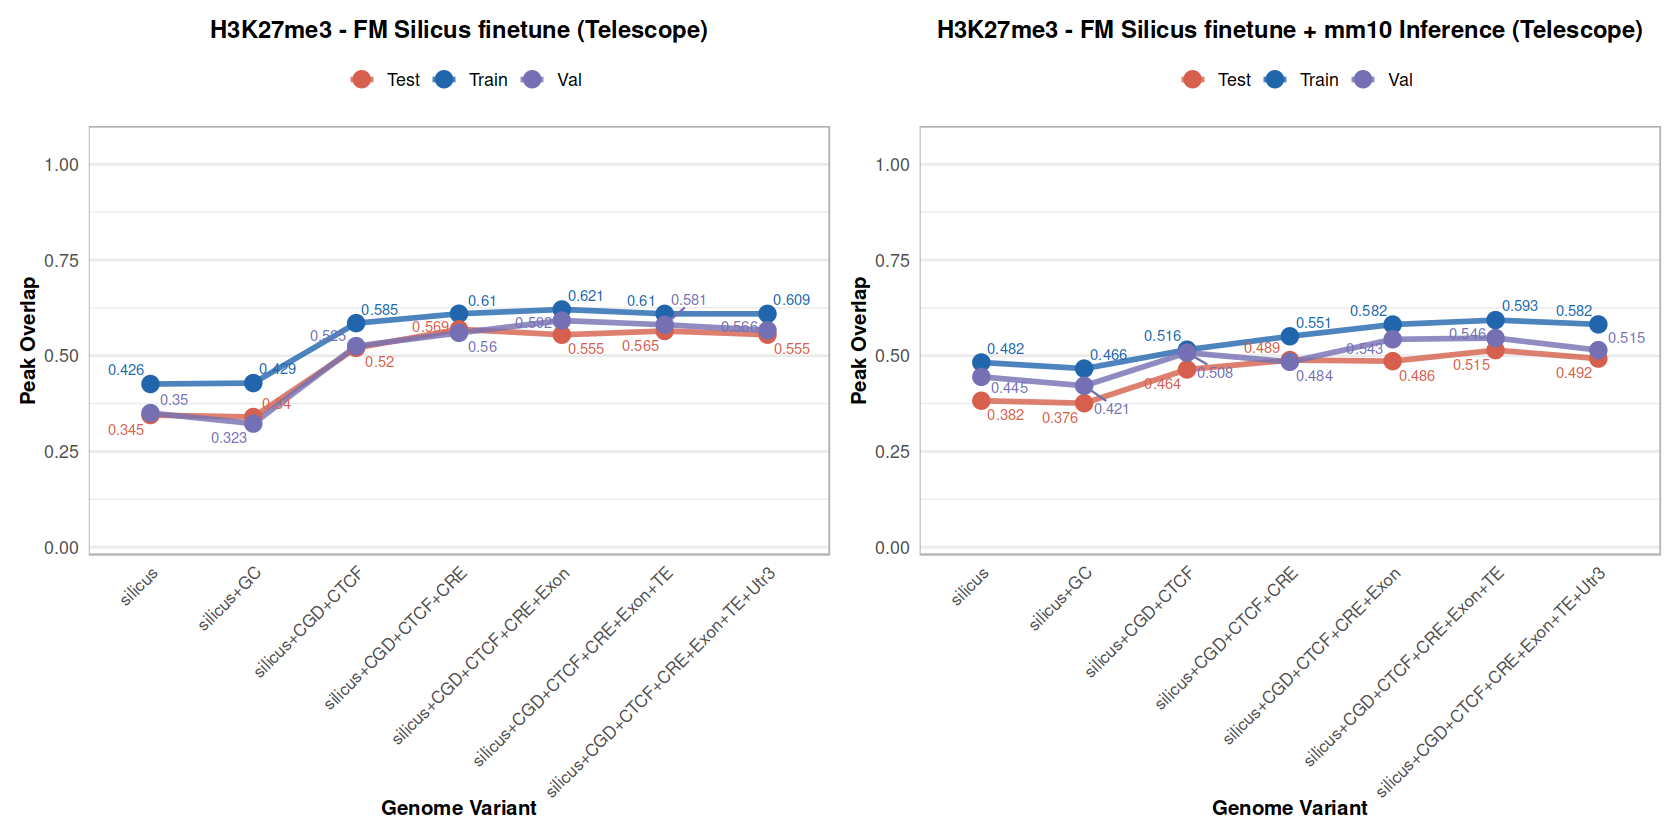

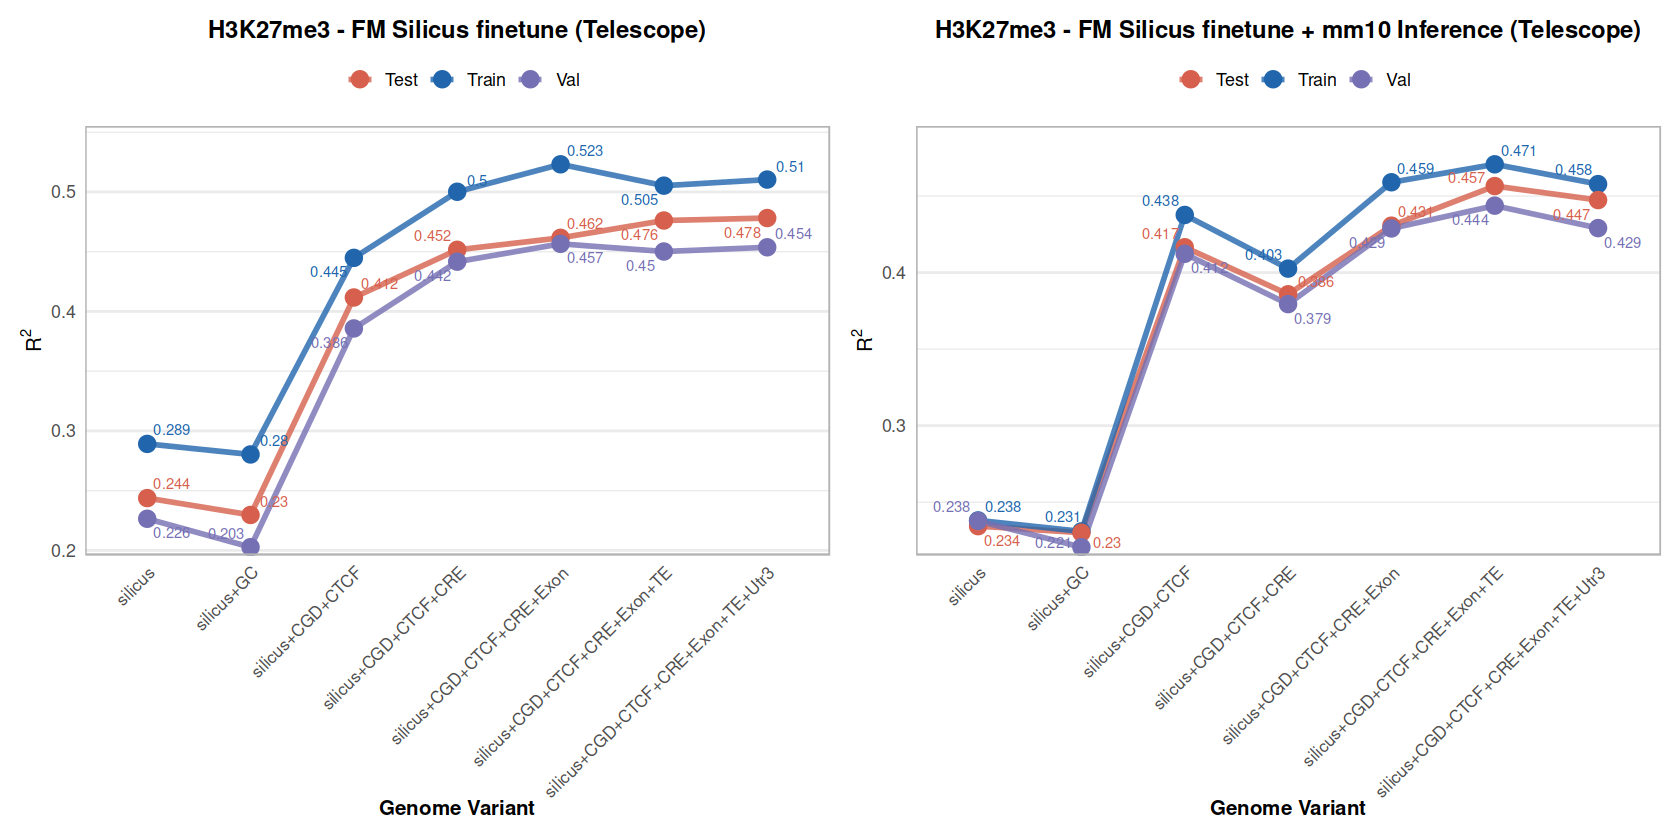

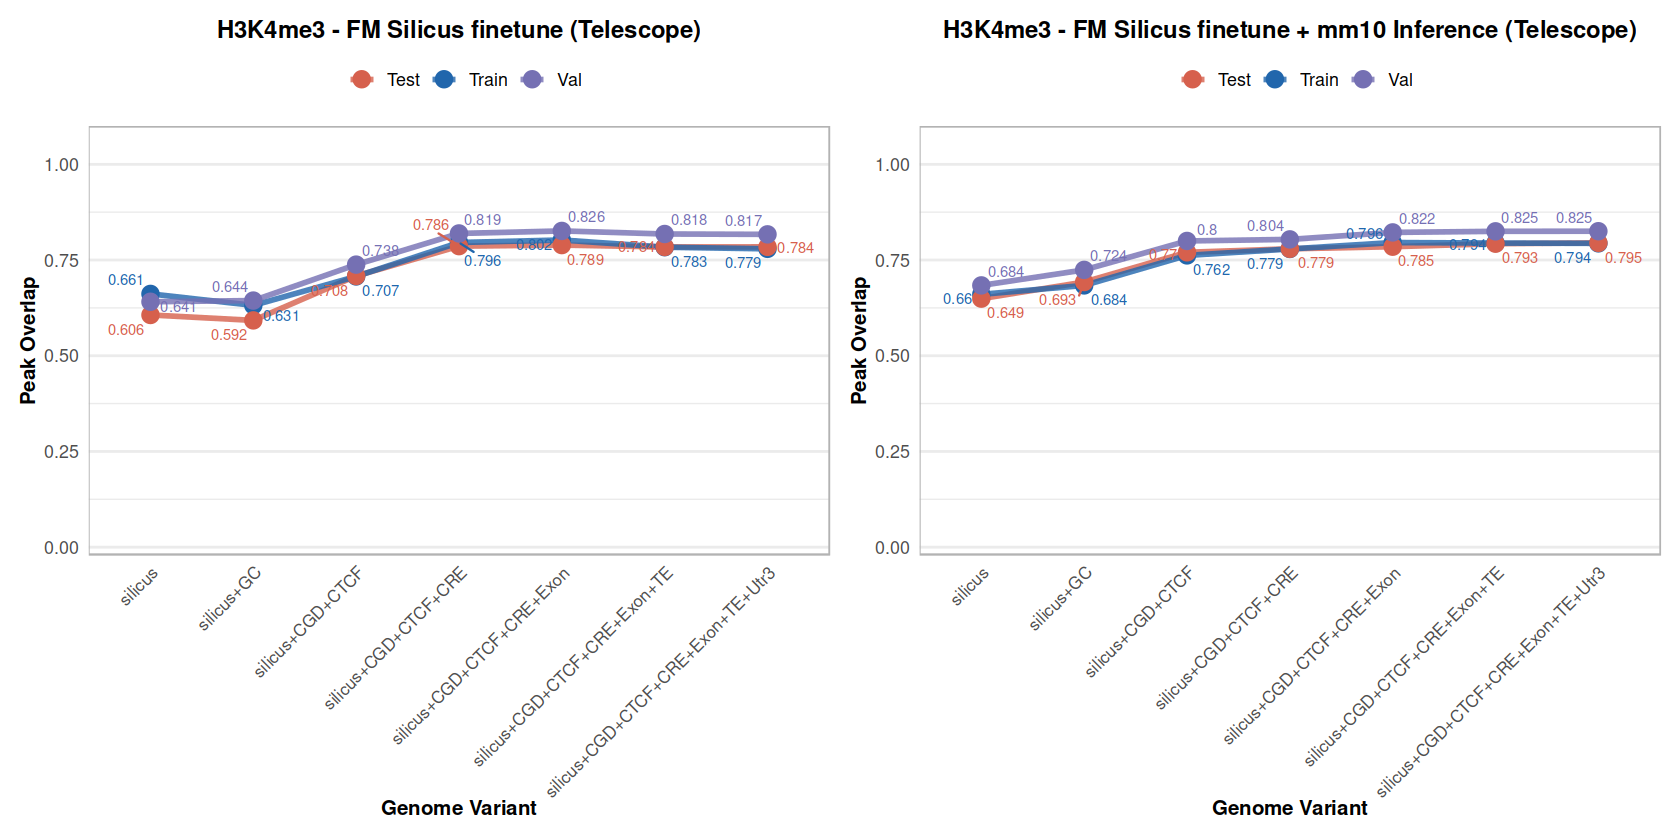

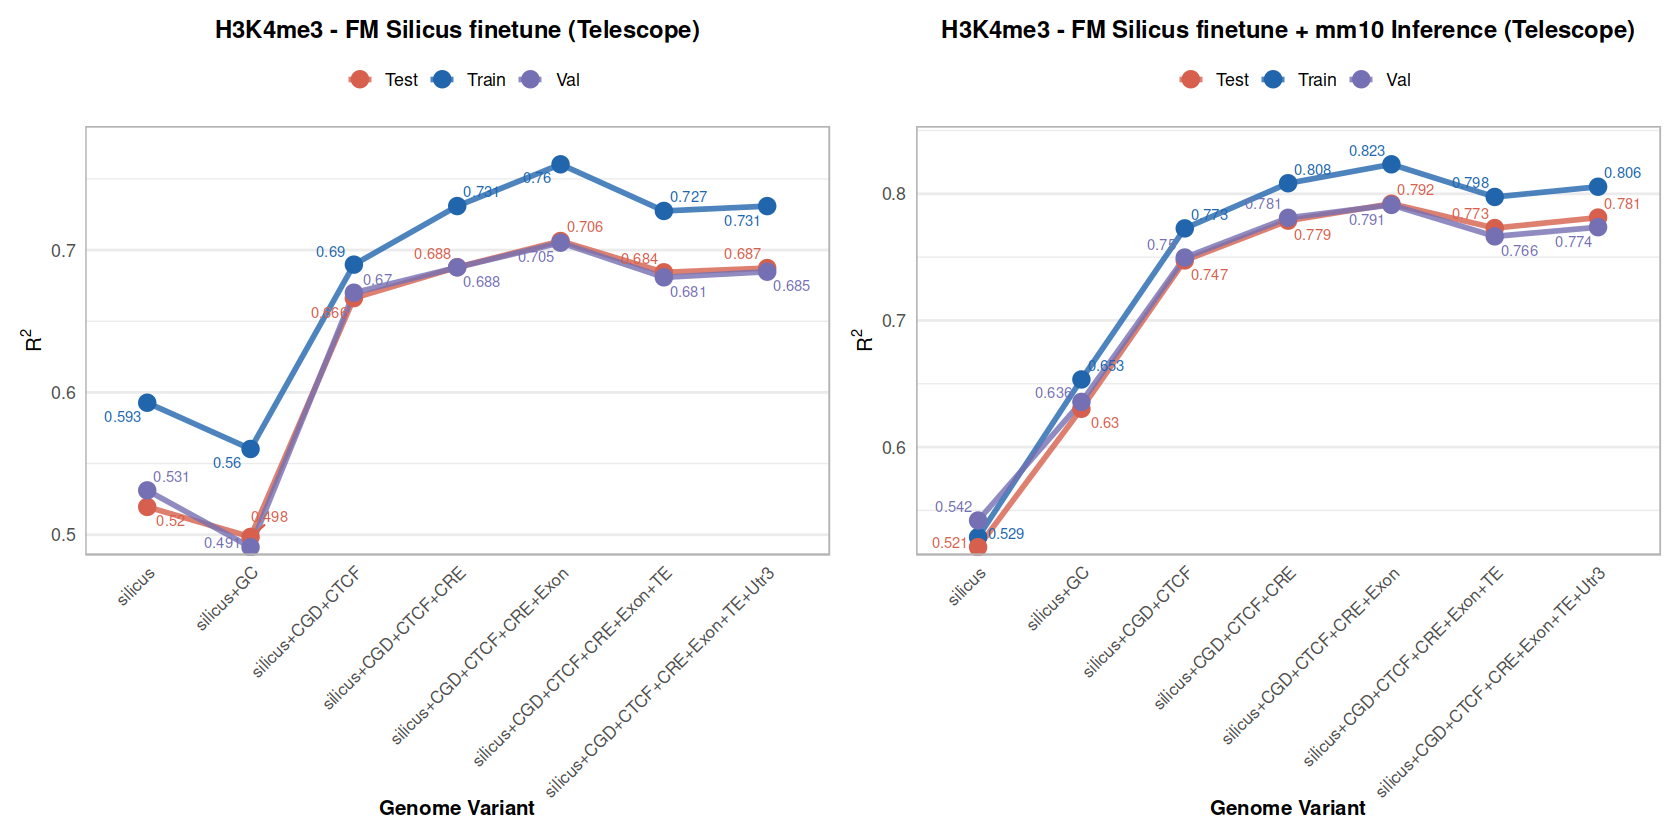

In [ ]:
# Create FM Silicus+ plots

# K27 overlap plots - silicus and mm10 inference
p_fm_sil_overlap_k27_sil <- plot_fm_silicus_series(overlap_fm_sil_k27, "H3K27me3", "silicus", "overlap", "(Telescope)")
p_fm_sil_overlap_k27_mm10 <- plot_fm_silicus_series(overlap_fm_sil_k27, "H3K27me3", "mm10", "overlap", "(Telescope)")

# K27 rsqr plots - silicus and mm10 inference
p_fm_sil_rsqr_k27_sil <- plot_fm_silicus_series(rsqr_fm_sil_k27, "H3K27me3", "silicus", "rsqr", "(Telescope)")
p_fm_sil_rsqr_k27_mm10 <- plot_fm_silicus_series(rsqr_fm_sil_k27, "H3K27me3", "mm10", "rsqr", "(Telescope)")

# K4 overlap plots
p_fm_sil_overlap_k4_sil <- plot_fm_silicus_series(overlap_fm_sil_k4, "H3K4me3", "silicus", "overlap", "(Telescope)")
p_fm_sil_overlap_k4_mm10 <- plot_fm_silicus_series(overlap_fm_sil_k4, "H3K4me3", "mm10", "overlap", "(Telescope)")

# K4 rsqr plots
p_fm_sil_rsqr_k4_sil <- plot_fm_silicus_series(rsqr_fm_sil_k4, "H3K4me3", "silicus", "rsqr", "(Telescope)")
p_fm_sil_rsqr_k4_mm10 <- plot_fm_silicus_series(rsqr_fm_sil_k4, "H3K4me3", "mm10", "rsqr", "(Telescope)")

# Display K27 plots
sps(14, 7)
print(p_fm_sil_overlap_k27_sil + p_fm_sil_overlap_k27_mm10)
print(p_fm_sil_rsqr_k27_sil + p_fm_sil_rsqr_k27_mm10)

# Display K4 plots
print(p_fm_sil_overlap_k4_sil + p_fm_sil_overlap_k4_mm10)
print(p_fm_sil_rsqr_k4_sil + p_fm_sil_rsqr_k4_mm10)

In [ ]:
# Define path
ppt_path_tel <- here("figures/silicus_telescope_performance.pptx")

# 1. Define the mapping for short labels
telescope_mapping <- c(
    "silicus" = "silicus",
    "silicus+CGD" = "+CGD",
    "silicus+CGD+CRE" = "+CRE",
    "silicus+CGD+CRE+CTCF" = "+CTCF",
    "silicus+CGD+CRE+CTCF+Exon" = "+Exon",
    "silicus+CGD+CRE+CTCF+Exon+TE" = "+TE"
)

# Define the new order for the plot x-axis
telescope_short_levels <- c("silicus", "+CGD", "+CRE", "+CTCF", "+Exon", "+TE")

# --- 2. K27 Overlap Plot (Short Labels) ---
p_k27_tel_overlap_ppt <- plot_performance(
    overlap_k27 %>% 
        filter(series == "silicusTelescope") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "overlap",
    mark_label = "H3K27me3",
    series_filter = NULL,  # Already filtered above
    title_suffix = "(Telescope)",
    x_levels = telescope_short_levels,
    baseline_data = NULL,  # No baseline lines
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, 
    text_size = 2, 
    line_width = 0.5
) +
    ylim(0, 0.8) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    ggtitle("")

# Export Overlap
tgppt::plot_gg_ppt(
    p_k27_tel_overlap_ppt, 
    ppt_path_tel, 
    width = 6, 
    height = 4, 
    sep_legend = TRUE, 
    overwrite = TRUE
)

# --- 3. K27 R^2 Plot (Short Labels) ---
p_k27_tel_rsqr_ppt <- plot_performance(
    rsqr_k27 %>% 
        filter(series == "silicusTelescope") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "rsqr",
    mark_label = "H3K27me3",
    series_filter = NULL,  # Already filtered above
    title_suffix = "(Telescope)",
    x_levels = telescope_short_levels,
    baseline_data = NULL,  # No baseline lines
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, 
    text_size = 2, 
    line_width = 0.5
) +
    ylim(0, 0.8) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    ggtitle("")

# Export R^2 (Append)
tgppt::plot_gg_ppt(
    p_k27_tel_rsqr_ppt, 
    ppt_path_tel, 
    width = 6, 
    height = 4, 
    sep_legend = TRUE, 
    overwrite = FALSE
)

message("Silicus Telescope (short labels) plots saved to ", ppt_path_tel)

In [ ]:
library(patchwork)

# --- 1. Prepare Data & Helpers ---

# Shared Y-axis limit for alignment
common_ylim <- c(0, 0.8)

# Helper to clean Y-axis for inner plots (removes labels/ticks for tighter packing)
clean_y_axis <- function() {
    theme(
        axis.title.y = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank()
    )
}

# Levels for x-axes
mm10_short_levels <- c("-CGD", "-CRE", "-CTCF", "-Exon", "-TE", "10% Synt.")
tel_short_levels <- c("silicus", "+CGD", "+CRE", "+CTCF", "+Exon", "+TE")
telescope_mapping <- c(
    "silicus" = "silicus", "silicus+CGD" = "+CGD", "silicus+CGD+CRE" = "+CRE",
    "silicus+CGD+CRE+CTCF" = "+CTCF", "silicus+CGD+CRE+CTCF+Exon" = "+Exon", 
    "silicus+CGD+CRE+CTCF+Exon+TE" = "+TE"
)

# --- 2. Create Row 1: Peak Overlap ---

# Plot 1: FM Receptive Field (Overlap)
p1_overlap_fm <- plot_rf_comparison_overlap(
    overlap_rf_k27, "H3K27me3", "fm", "", show_val = FALSE,
    point_size = 1.5, text_size = 2, line_width = 0.5, max.overlaps = 2
) +
    ggtitle("") + ylab("Peak Overlap") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs()

# Plot 2: mm10Minus (Overlap)
p2_overlap_minus <- plot_performance(
    overlap_k27 %>% 
        filter(series == "mm10Minus") %>% 
        mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
        mutate(genome_label = gsub("-Random", "10% Synt.", genome_label)) %>% 
        filter(!grepl("pad", genome_label)), 
    metric = "overlap",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = mm10_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis() # Remove y-axis for alignment

# Plot 3: Telescope (Overlap)
p3_overlap_tel <- plot_performance(
    overlap_k27 %>% 
        filter(series == "silicusTelescope") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "overlap",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# --- 3. Create Row 2: R^2 ---

# Plot 4: FM Receptive Field (R2)
p4_rsqr_fm <- plot_rf_comparison_rsqr(
    rsqr_rf_k27, "H3K27me3", "fm", "", show_val = FALSE,
    point_size = 1.5, text_size = 2, line_width = 0.5, max.overlaps = 2
) +
    ggtitle("") + ylab(expression(R^2)) +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs()

# Plot 5: mm10Minus (R2)
p5_rsqr_minus <- plot_performance(
    rsqr_k27 %>% 
        filter(series == "mm10Minus") %>% 
        mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
        mutate(genome_label = gsub("-Random", "10% Synt.", genome_label)) %>% 
        filter(!grepl("pad", genome_label)), 
    metric = "rsqr",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = mm10_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# Plot 6: Telescope (R2)
p6_rsqr_tel <- plot_performance(
    rsqr_k27 %>% 
        filter(series == "silicusTelescope") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "rsqr",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# --- 4. Combine with Patchwork & Export ---

# Combine plots: (Row 1) over (Row 2), collecting guides
combined_plot <- (p1_overlap_fm | p2_overlap_minus | p3_overlap_tel) /
                 (p4_rsqr_fm | p5_rsqr_minus | p6_rsqr_tel) +
                 plot_layout(guides = "collect", axis_titles = "collect") & 
                 theme(legend.position = "top", 
                       plot.margin = margin(5, 5, 5, 5))

# Export to single slide
ppt_path_all <- here("figures/k27_all_comparison.pptx")
tgppt::plot_base_ppt(print(combined_plot), ppt_path_all, width = 18, height = 12, overwrite = TRUE) # Wider width for 3 columns

message("Combined aligned plot saved to ", ppt_path_all)

In [ ]:
browser()

In [ ]:
gdb.reload()
# 1. Define the new tracks in a table
new_tracks_tbl <- tribble(
  ~track_name, ~col_name, ~mark, ~label,
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExonTE.metrics.loss.ft_524k_EB4_cnt_cropped",      "ft_silicusPlusCGDCreCtcfExonTE_k27",  "K27", "Finetuned (Silicus Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExonTE.metrics.loss.ft_mm10_524k_EB4_cnt_cropped", "ft_silicusPlusCGDCreCtcfExonTE_mm10_k27", "K27", "Finetuned (mm10 Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExonTE.metrics.iou.ft_524k_EB4_cnt_cropped", "ft_silicusPlusCGDCreCtcfExonTE_metrics_iou_k27", "K27", "Finetuned (Silicus Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExonTE.metrics.iou.ft_mm10_524k_EB4_cnt_cropped", "ft_silicusPlusCGDCreCtcfExonTE_metrics_iou_mm10_k27", "K27", "Finetuned (mm10 Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExonTE.metrics.pearson.ft_524k_EB4_cnt_cropped", "ft_silicusPlusCGDCreCtcfExonTE_metrics_pearson_k27", "K27", "Finetuned (Silicus Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCreCtcfExonTE.rf524k_EB4_cnt", "rf524k_silicusPlusCGDCreCtcfExonTE_k27", "K27", "Pre-trained (Silicus Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCre.metrics.loss.ft_524k_EB4_cnt_cropped", "ft_silicusPlusCGDCre_k27", "K27", "Finetuned (Silicus Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCre.metrics.loss.ft_mm10_524k_EB4_cnt_cropped", "ft_silicusPlusCGDCre_mm10_k27", "K27", "Finetuned (mm10 Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCre.metrics.iou.ft_524k_EB4_cnt_cropped", "ft_silicusPlusCGDCre_metrics_iou_k27", "K27", "Finetuned (Silicus Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCre.metrics.iou.ft_mm10_524k_EB4_cnt_cropped", "ft_silicusPlusCGDCre_metrics_iou_mm10_k27", "K27", "Finetuned (mm10 Inf)",
  "seq.IQ.pcg.flashzoi.silicusPlusCGDCre.metrics.pearson.ft_524k_EB4_cnt_cropped", "ft_silicusPlusCGDCre_metrics_pearson_k27", "K27", "Finetuned (Silicus Inf)"
)

# 2. Compute Peak Overlap
message("Computing Peak Overlap...")
new_overlap <- compute_all_track_peak_overlaps(
    track_tbl = new_tracks_tbl,
    obs_track_name = CONFIG$obs_k27_track,
    context_size = CONFIG$context_size, 
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms, 
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size, 
    n_cores = CONFIG$n_cores
) 

print(new_overlap)


In [ ]:

# # 3. Compute R^2
# message("Computing R^2...")

# # Calculate for each split
# r2_train <- calc_rsqr_gcor(new_tracks_tbl$track_name, new_tracks_tbl$col_name, obs_k27_expr, intervals_train, intervals_train) 
# r2_test  <- calc_rsqr_gcor(new_tracks_tbl$track_name, new_tracks_tbl$col_name, obs_k27_expr, intervals_test, intervals_test) 
# r2_val   <- calc_rsqr_gcor(new_tracks_tbl$track_name, new_tracks_tbl$col_name, obs_k27_expr, intervals_val, intervals_val)

# # Combine R^2 results
# new_rsqr <- tibble(
#     col_name = names(r2_train),
#     r2_train = r2_train^2,
#     r2_test  = r2_test^2,
#     r2_val   = r2_val^2
# )

# # 4. Join and Print Summary
# summary_stats <- new_tracks_tbl %>%
#     select(label, col_name) %>%
#     left_join(new_overlap %>% select(col_name, train_p, test_p, val_p), by = "col_name") %>%
#     left_join(new_rsqr, by = "col_name")

# print(summary_stats)

In [ ]:
browser()

## rf524k variants

In [ ]:
# Compare rf524k variant tracks

variant_base <- c(
    "from_scratch_norm_4k_EB4_cnt_cropped",
    "from_scratch_norm_524k_EB4_cnt_cropped",
    "from_scratch_norm_524k_lr_1eminus5_EB4_cnt_cropped",
    "from_scratch_norm_524k_lr_1eminus5_EB4_cnt_val_genome_wide_pearson",
    "from_scratch_norm_524k_lr_1eminus5_EB4_cnt_val_iou",
    "from_scratch_norm_524k_lr_1eminus4_EB4_cnt_cropped",
    "from_scratch_norm_524k_lr_1eminus4_EB4_cnt_val_iou",
    "from_scratch_norm_524k_lr_1eminus4_EB4_cnt_val_genome_wide_pearson",
    "from_scratch_norm_524k_lr_1eminus4_EB4_cnt_last"
)

variant_tbl <- tibble(
    variant_base = variant_base,
    order = seq_along(variant_base)
) %>%
    mutate(
        track_name_k27 = paste0("seq.IQ.pcg.flashzoi.", variant_base),
        track_name_k4 = paste0("seq.IQ.pcg.flashzoi.", str_replace(variant_base, "_EB4_cnt", "_EB4_cnt_k4"))
    ) %>%
    pivot_longer(cols = starts_with("track_name_"), names_to = "mark", values_to = "track_name") %>%
    mutate(
        mark = if_else(mark == "track_name_k27", "K27", "K4"),
        variant = str_replace(track_name, "^seq\\.IQ\\.pcg\\.flashzoi\\.", ""),
        variant_base = str_replace(variant, "_k4", ""),
        col_name = paste0(variant_base, "_", tolower(mark))
    ) %>%
    select(variant_base, order, mark, track_name, col_name)

missing_variant_tracks <- variant_tbl$track_name[!sapply(variant_tbl$track_name, gtrack.exists)]
if (length(missing_variant_tracks) > 0) {
    message("WARNING: Missing rf524k variant tracks:")
    print(missing_variant_tracks)
}

variant_k27 <- variant_tbl %>% filter(mark == "K27")
variant_k4 <- variant_tbl %>% filter(mark == "K4")

message("Computing peak overlap for rf524k variant K27 tracks...")
overlap_variant_k27 <- compute_all_track_peak_overlaps(
    track_tbl = variant_k27,
    obs_track_name = CONFIG$obs_k27_track,
    context_size = CONFIG$context_size, T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms, val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size, n_cores = CONFIG$n_cores
) %cache_rds% file.path(CONFIG$output_dir, "overlap-variant-k27.rds")

message("Computing peak overlap for rf524k variant K4 tracks...")
overlap_variant_k4 <- compute_all_track_peak_overlaps(
    track_tbl = variant_k4,
    obs_track_name = CONFIG$obs_k4_track,
    context_size = CONFIG$context_size, T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms, val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size, n_cores = CONFIG$n_cores
) %cache_rds% file.path(CONFIG$output_dir, "overlap-variant-k4.rds")

overlap_variant_all <- bind_rows(overlap_variant_k27, overlap_variant_k4)

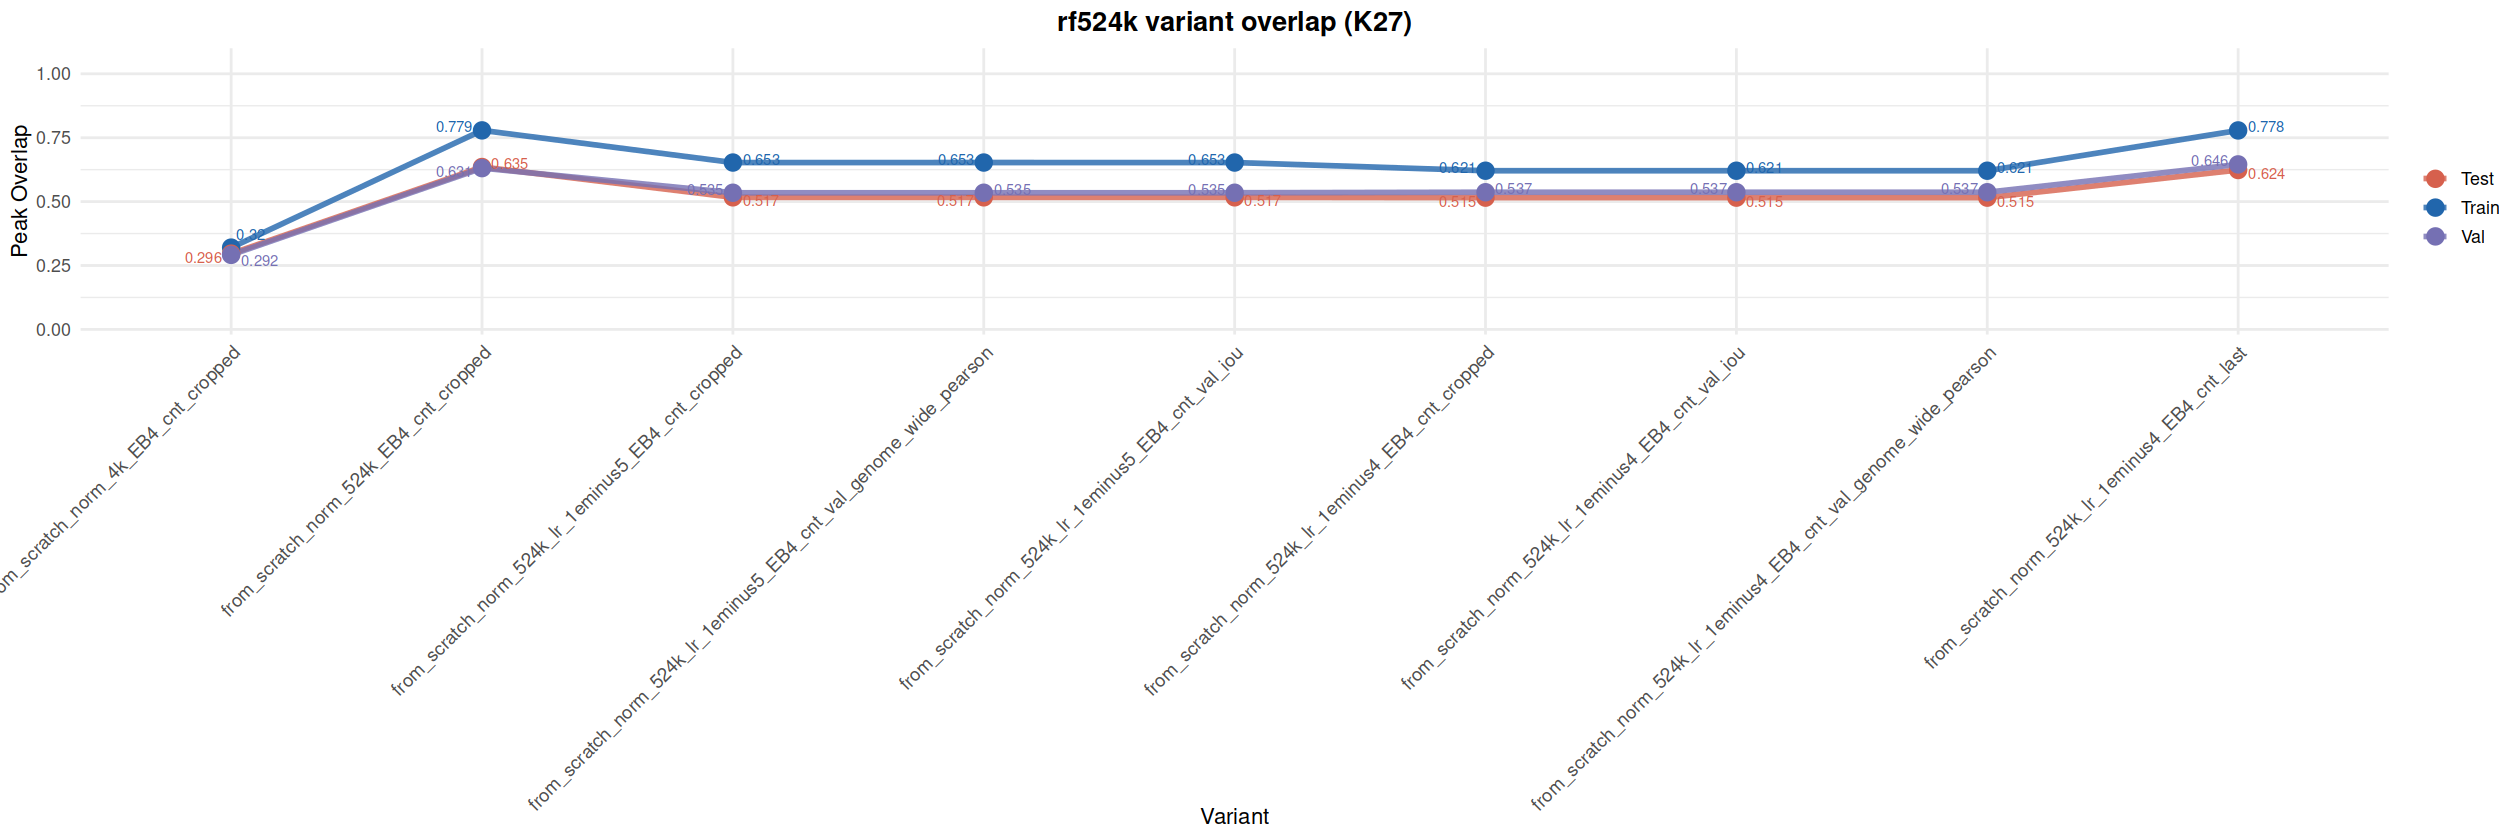

In [12]:
# Plot overlap performance comparison (K27 only)
variant_overlap_df <- overlap_variant_all %>%
    filter(mark == "K27") %>%
    select(variant_base, order, train_p, test_p, val_p) %>%
    arrange(order) %>%
    mutate(variant_base = factor(variant_base, levels = unique(variant_base)))

variant_overlap_long <- variant_overlap_df %>%
    pivot_longer(cols = c(train_p, test_p, val_p), names_to = "dataset", values_to = "overlap") %>%
    mutate(dataset = c(train_p = "Train", test_p = "Test", val_p = "Val")[dataset])

p_variant_overlap <- ggplot(variant_overlap_long, aes(x = variant_base, y = overlap, color = dataset, group = dataset)) +
    geom_line(linewidth = 1.2, alpha = 0.8) +
    geom_point(size = 4) +
    geom_text_repel(aes(label = round(overlap, 3)), size = 3, max.overlaps = 20, box.padding = 0.3, show.legend = FALSE) +
    scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
    scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0.02, 0.1))) +
    labs(title = "rf524k variant overlap (K27)", x = "Variant", y = "Peak Overlap", color = "") +
    theme_minimal(base_size = 13) +
    theme(plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1, size = 11))

print(p_variant_overlap)

In [ ]:
# Compute R^2 for rf524k variants
message("Calculating R^2 for rf524k variant tracks...")

cor_variant_k27_train <- calc_rsqr_gcor(variant_k27$track_name, variant_k27$col_name, obs_k27_expr, intervals_train, intervals_train) %cache_rds% file.path(CONFIG$output_dir, "rsqr-variant-k27-train.rds")
cor_variant_k27_test <- calc_rsqr_gcor(variant_k27$track_name, variant_k27$col_name, obs_k27_expr, intervals_test, intervals_test) %cache_rds% file.path(CONFIG$output_dir, "rsqr-variant-k27-test.rds")
cor_variant_k27_val <- calc_rsqr_gcor(variant_k27$track_name, variant_k27$col_name, obs_k27_expr, intervals_val, intervals_val) %cache_rds% file.path(CONFIG$output_dir, "rsqr-variant-k27-val.rds")

cor_variant_k4_train <- calc_rsqr_gcor(variant_k4$track_name, variant_k4$col_name, obs_k4_expr, intervals_train, intervals_train) %cache_rds% file.path(CONFIG$output_dir, "rsqr-variant-k4-train.rds")
cor_variant_k4_test <- calc_rsqr_gcor(variant_k4$track_name, variant_k4$col_name, obs_k4_expr, intervals_test, intervals_test) %cache_rds% file.path(CONFIG$output_dir, "rsqr-variant-k4-test.rds")
cor_variant_k4_val <- calc_rsqr_gcor(variant_k4$track_name, variant_k4$col_name, obs_k4_expr, intervals_val, intervals_val) %cache_rds% file.path(CONFIG$output_dir, "rsqr-variant-k4-val.rds")

rsqr_variant_all <- bind_rows(
    data.frame(col_name = names(cor_variant_k27_train), r2_train = cor_variant_k27_train^2, 
               r2_test = cor_variant_k27_test^2, r2_val = cor_variant_k27_val^2, stringsAsFactors = FALSE),
    data.frame(col_name = names(cor_variant_k4_train), r2_train = cor_variant_k4_train^2, 
               r2_test = cor_variant_k4_test^2, r2_val = cor_variant_k4_val^2, stringsAsFactors = FALSE)
) %>%
    left_join(variant_tbl %>% select(col_name, variant_base, order, mark), by = "col_name")

variant_metrics <- rsqr_variant_all %>%
    left_join(overlap_variant_all %>% select(col_name, train_p, test_p, val_p), by = "col_name")

message("\nrf524k variant performance:")
print(variant_metrics %>% filter(mark == "K27") %>% select(variant_base, r2_train, r2_test, r2_val, train_p, test_p, val_p))

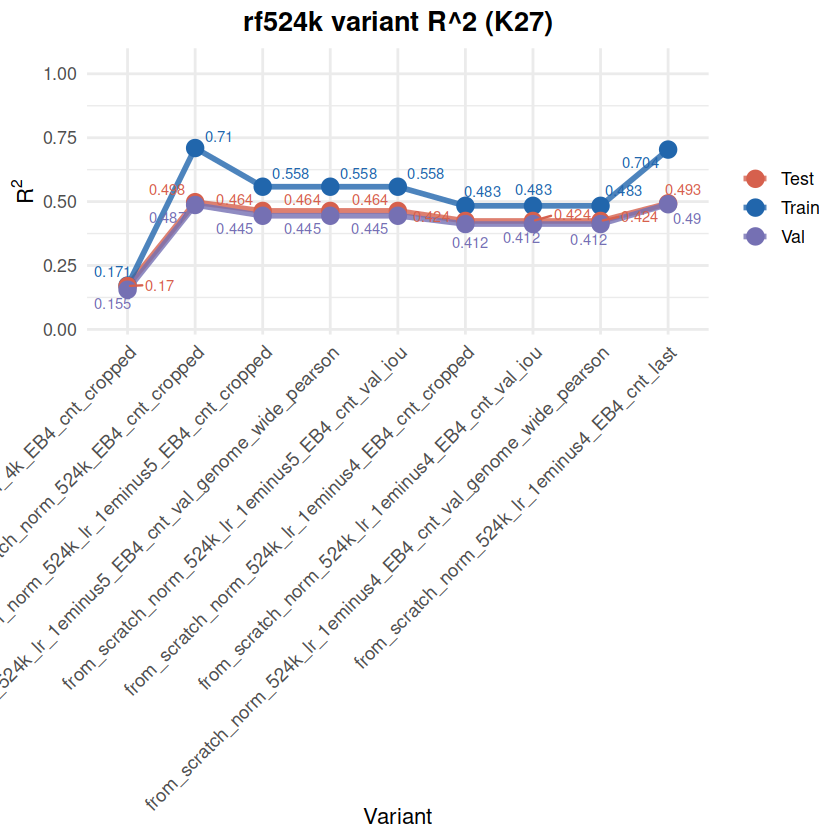

In [14]:
# Plot R^2 performance comparison (K27 only)
variant_r2_df <- rsqr_variant_all %>%
    filter(mark == "K27") %>%
    select(variant_base, order, r2_train, r2_test, r2_val) %>%
    arrange(order) %>%
    mutate(variant_base = factor(variant_base, levels = unique(variant_base)))

variant_r2_long <- variant_r2_df %>%
    pivot_longer(cols = c(r2_train, r2_test, r2_val), names_to = "dataset", values_to = "r2") %>%
    mutate(dataset = c(r2_train = "Train", r2_test = "Test", r2_val = "Val")[dataset])

p_variant_r2 <- ggplot(variant_r2_long, aes(x = variant_base, y = r2, color = dataset, group = dataset)) +
    geom_line(linewidth = 1.2, alpha = 0.8) +
    geom_point(size = 4) +
    geom_text_repel(aes(label = round(r2, 3)), size = 3, max.overlaps = 20, box.padding = 0.3, show.legend = FALSE) +
    scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
    scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0.02, 0.1))) +
    labs(title = "rf524k variant R^2 (K27)", x = "Variant", y = expression(R^2), color = "") +
    theme_minimal(base_size = 13) +
    theme(plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1, size = 11))

sps(7, 7)
print(p_variant_r2)

In [15]:
message("Extracting track values for linear model...")

lm_data <- gextract(
    "seq.IQ.pcg.flashzoi.mm10.rf524k_EB4_cnt",
    "jk.epipcg.pred.eb4_xgb_lm_seeds",
    "jk.epipcg.pred.eb4_xgb_brz2k_seeds",
    "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm",
    intervals = cg_trace_f,
    iterator = cg_trace_f,
    colnames = c("flash524k", "sns_lm", "sns_brz2k", "obs_k27")
) %>%
    mutate(
        log_obs = log2(1 + obs_k27),
        split = case_when(
            chrom %in% test_chroms ~ "test",
            chrom %in% val_chroms ~ "val",
            TRUE ~ "train"
        )
    )

# Fit linear models on train set
train_data <- lm_data %>% filter(split == "train")

# Individual models
fit_flash <- lm(log_obs ~ flash524k, data = train_data)
fit_sns_lm <- lm(log_obs ~ sns_lm, data = train_data)
fit_sns_brz <- lm(log_obs ~ sns_brz2k, data = train_data)

# Combined models
fit_flash_sns_lm <- lm(log_obs ~ flash524k + sns_lm, data = train_data)
fit_flash_sns_brz <- lm(log_obs ~ flash524k + sns_brz2k, data = train_data)
fit_all <- lm(log_obs ~ flash524k + sns_lm + sns_brz2k, data = train_data)

# Function to compute R^2 on a dataset
calc_r2 <- function(model, data) {
    pred <- predict(model, newdata = data)
    cor(pred, data$log_obs, use = "pairwise.complete.obs")^2
}

# Evaluate all models on train/test/val
models <- list(
    flash524k = fit_flash,
    sns_lm = fit_sns_lm,
    sns_brz2k = fit_sns_brz,
    `flash524k + sns_lm` = fit_flash_sns_lm,
    `flash524k + sns_brz2k` = fit_flash_sns_brz,
    `flash524k + sns_lm + sns_brz2k` = fit_all
)

test_data <- lm_data %>% filter(split == "test")
val_data <- lm_data %>% filter(split == "val")

lm_results <- tibble(
    model = names(models),
    r2_train = sapply(models, calc_r2, data = train_data),
    r2_test = sapply(models, calc_r2, data = test_data),
    r2_val = sapply(models, calc_r2, data = val_data)
)

message("\nLinear model R^2 comparison:")
print(lm_results)

# Show coefficients for combined models
message("\nCoefficients for flash524k + sns_lm:")
print(summary(fit_flash_sns_lm)$coefficients)

message("\nCoefficients for flash524k + sns_brz2k:")
print(summary(fit_flash_sns_brz)$coefficients)

Extracting track values for linear model...


Linear model R^2 comparison:



# A tibble: 6 x 4
                           model  r2_train   r2_test    r2_val
1                      flash524k 0.7095988 0.4978188 0.4867921
2                         sns_lm 0.3622929 0.3354600 0.3120384
3                      sns_brz2k 0.4061871 0.3654501 0.3672297
4             flash524k + sns_lm 0.7103086 0.5008125 0.4896578
5          flash524k + sns_brz2k 0.7100614 0.5011320 0.4905605
6 flash524k + sns_lm + sns_brz2k 0.7103142 0.5010715 0.4900032



Coefficients for flash524k + sns_lm:



              Estimate    Std. Error   t value Pr(>|t|)
(Intercept) 1.37095820 0.00041017282 3342.3917        0
flash524k   0.20666257 0.00007606768 2716.8249        0
sns_lm      0.01378194 0.00011233000  122.6915        0



Coefficients for flash524k + sns_brz2k:



              Estimate   Std. Error    t value Pr(>|t|)
(Intercept) 1.38210964 0.0003804291 3633.02865        0
flash524k   0.20714242 0.0000816291 2537.60497        0
sns_brz2k   0.01103529 0.0001114601   99.00659        0


In [19]:
# Combine flash524k with SNS brz2k predictions using glmnet

library(glmnet)

message("Extracting track values for linear model...")

gvtrack.create("flash524k", "seq.IQ.pcg.flashzoi.mm10.rf524k_EB4_cnt", func = "sum", sshift = -200, eshift = 200)
gvtrack.create("sns_brz2k", "jk.epipcg.pred.eb4_xgb_brz2k_seeds", func = "sum", sshift = -200, eshift = 200)
gvtrack.create("sns_lm", "jk.epipcg.pred.eb4_xgb_lm_seeds", func = "sum", sshift = -200, eshift = 200)
gvtrack.create("obs_k27", "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm", func = "sum", sshift = -200, eshift = 200)

lm_data <- gextract(c("flash524k", "sns_brz2k", "sns_lm", "obs_k27"), iterator = 100, intervals = gintervals.all()) %>%
    mutate(
        log_obs = log2(1 + obs_k27),
        split = case_when(
            chrom %in% test_chroms ~ "test",
            chrom %in% val_chroms ~ "val",
            TRUE ~ "train"
        )
    ) %>%
    filter(!is.na(flash524k) & !is.na(sns_brz2k) & !is.na(sns_lm) & !is.na(obs_k27))


Extracting track values for linear model...



In [21]:

# --- Compute peak overlap for combined prediction ---
message("\nComputing peak overlap for combined prediction...")

# Create prediction data frame for virtual track
combined_pred_df <- bind_rows(
    train_data %>% mutate(pred = pred_train),
    test_data %>% mutate(pred = pred_test),
    val_data %>% mutate(pred = pred_val)
) %>%
    select(chrom, start, end, pred) %>%
    arrange(chrom, start)

# Create virtual track from combined predictions
gvtrack.create("combined_pred", src = combined_pred_df, func = "avg")

# Compute overlap using the same approach as compute_track_peak_overlap
gvtrack.create("obs_tmp", "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm", "avg")
gvtrack.iterator("obs_tmp", sshift = -200, eshift = 200)
gvtrack.iterator("combined_pred", sshift = -200, eshift = 200)

q_obs <- gquantiles("obs_tmp", 0.98, iterator = 100)
q_pred <- gquantiles("combined_pred", 0.98, iterator = 100)

d_obs <- gscreen(paste0("obs_tmp > ", q_obs), iterator = 100)
d_pred <- gscreen(paste0("combined_pred > ", q_pred), iterator = 100)
d_both <- gintervals.intersect(d_obs, d_pred)

calc_overlap_p <- function(chroms) {
    f_pred <- d_pred$chrom %in% chroms
    f_both <- d_both$chrom %in% chroms
    pred_bp <- sum(d_pred$end[f_pred] - d_pred$start[f_pred])
    both_bp <- sum(d_both$end[f_both] - d_both$start[f_both])
    if (pred_bp > 0) both_bp / pred_bp else NA
}

all_chroms <- unique(d_pred$chrom)
train_chroms_lm <- setdiff(all_chroms, c(test_chroms, val_chroms))

overlap_combined <- c(
    train_p = calc_overlap_p(train_chroms_lm),
    test_p = calc_overlap_p(test_chroms),
    val_p = calc_overlap_p(val_chroms)
)

# Get flash524k and sns_brz2k overlap for comparison
overlap_flash <- overlap_k27 %>% filter(genome_label == "mm10") %>% select(train_p, test_p, val_p) %>% unlist()
overlap_sns_brz <- overlap_sns %>% filter(col_name == "sns_brz2k") %>% select(train_p, test_p, val_p) %>% unlist()

overlap_results <- tibble(
    model = c("flash524k", "sns_brz2k", "combined"),
    train_p = c(overlap_flash["train_p"], overlap_sns_brz["train_p"], overlap_combined["train_p"]),
    test_p = c(overlap_flash["test_p"], overlap_sns_brz["test_p"], overlap_combined["test_p"]),
    val_p = c(overlap_flash["val_p"], overlap_sns_brz["val_p"], overlap_combined["val_p"])
)

message("\nPeak overlap comparison:")
print(overlap_results)

# Cleanup
gvtrack.rm("combined_pred")
gvtrack.rm("obs_tmp")


Computing peak overlap for combined prediction...




Peak overlap comparison:



# A tibble: 3 x 4
      model   train_p    test_p     val_p
1 flash524k 0.7786554 0.6352778 0.6309726
2 sns_brz2k 0.6706545 0.6136320 0.6568082
3  combined 0.8591993 0.6985471 0.6964091
